# Notebook 3S v2 — Soil niche differentiation and negative-control compound modelling

This notebook replaces the previous Notebook 3S.

The previous Notebook 3S asked whether **SoilGrids-only predictors can predict taxon–compound medicinal evidence**. The result was chance-level, which is expected because SoilGrids predictors vary by taxon/location but not by compound identity.

This revised notebook changes the primary analysis.

## Main analysis

The main publishable analysis is now:

> **Soil niche differentiation among medicinal plant taxa using low-cost, balanced SoilGrids occurrence samples.**

The modelling unit for the main analysis is:

> **taxon × occurrence/spatial block**

not taxon × compound.

## Secondary analysis

The taxon–compound table is kept only as an **annotation layer** and as a **negative-control ML experiment**:

> Soil-only predictors do not generalize to compound-level medicinal-evidence labels.

That negative result is useful because it shows that soil alone is insufficient for compound prediction and should be integrated with climate, phytochemistry, pathway/genetic evidence, or measured metabolite concentrations.

## Main outputs

The notebook produces publication-ready outputs for:

1. Soil niche coverage and sampling balance.
2. Soil feature completeness.
3. PCA of SoilGrids niche space.
4. Taxon separation in soil niche space.
5. Taxon classification as a quantitative niche-differentiation test.
6. Feature importance for taxon soil niche differentiation.
7. Compound evidence annotation heatmap.
8. Negative-control compound-level ML panel.

## Claims supported

Supported:

> Low-cost, balanced SoilGrids sampling can characterize and compare soil niches of medicinal plant taxa.

> Soil-only predictors differentiate taxa/ecological niches better than they predict compound-level medicinal evidence.

Not supported:

> Soil causes metabolite accumulation.

> SoilGrids alone predicts salidroside or medicinal compound accumulation.

Causal or concentration-level claims require measured metabolite concentration data and appropriate environmental/genetic controls.

## 0. Recommended environment

CPU is sufficient. No GPU is needed.

```bash
conda create -n medicinal-soil-niche python=3.11 -y
conda activate medicinal-soil-niche
conda install -c conda-forge pandas numpy matplotlib scikit-learn scipy pyarrow pyyaml -y
```

In [14]:
# ============================================================
# 0. Imports
# ============================================================

import os
import re
import json
import math
import pathlib
import warnings
import datetime as dt
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

try:
    from scipy.stats import kruskal, mannwhitneyu, spearmanr
    from scipy.cluster.hierarchy import linkage, leaves_list
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 220)

In [15]:
# ============================================================
# 1. Configuration
# ============================================================

CONFIG = {
    "project_dir": "soilgrids_notebook3S_v2_soil_niche_outputs",

    "input_dirs": [
        ".",
        "/content",
        "/mnt/data",
        "/content/soilgrids_notebook2_outputs",
        "/content/soilgrids_notebook2_outputs/derived",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost/derived",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost/soilgrids",
        "/mnt/data/soilgrids_notebook2_outputs",
    ],

    # Main modelling target for soil niche analysis.
    "taxon_target_col": "taxon_id",

    # Compound evidence targets are used only for annotation and negative-control ML.
    "binary_compound_target_col": "target_label_for_open_data_classifier",
    "ordinal_compound_target_col": "target_evidence_score",

    # Minimum group sizes for stable taxon niche classification.
    "min_taxon_occurrences_for_classification": 20,
    "n_group_folds": 5,

    # Negative-control settings.
    "n_label_permutations": 200,

    # Figure export.
    "figure_dpi": 300,
    "save_pdf": True,

    "random_seed": 42,
}

PROJECT = pathlib.Path(CONFIG["project_dir"]).resolve()
DIRS = {
    "derived": PROJECT / "derived",
    "figures": PROJECT / "figures",
    "tables": PROJECT / "tables",
    "logs": PROJECT / "logs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
CONFIG["run_id"] = RUN_ID
CONFIG["created_utc"] = dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")

with open(PROJECT / "notebook3S_v2_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

PROJECT

PosixPath('/content/soilgrids_notebook3S_v2_soil_niche_outputs')

In [16]:
# ============================================================
# 2. Utility functions
# ============================================================

def safe_name(x: str, max_len: int = 160) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")[:max_len]

def find_input_file(filename: str, required=True):
    candidates = []
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        candidates.append(d / filename)
        if d.exists() and d.is_dir():
            candidates.extend(d.rglob(filename))
    existing = sorted(set([p for p in candidates if p.exists() and p.stat().st_size > 0]), key=lambda p: (len(str(p)), str(p)))
    if not existing:
        if required:
            raise FileNotFoundError(f"Could not find {filename}. Add its folder to CONFIG['input_dirs'].")
        return None
    return existing[0]

def load_tsv_any(filenames, required=True):
    for fn in filenames:
        p = find_input_file(fn, required=False)
        if p is not None:
            df = pd.read_csv(p, sep="\t", dtype=str, low_memory=False)
            df.attrs["source_path"] = str(p)
            print(f"Loaded {fn}: {df.shape} from {p}")
            return df
    if required:
        raise FileNotFoundError(f"None of these files were found: {filenames}")
    print("Optional files not found:", filenames)
    return pd.DataFrame()

def write_table(df: pd.DataFrame, path_stem: pathlib.Path):
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    tsv = path_stem.with_suffix(".tsv")
    df.to_csv(tsv, sep="\t", index=False)
    try:
        df.to_parquet(path_stem.with_suffix(".parquet"), index=False)
    except Exception as e:
        print(f"Parquet skipped for {path_stem.name}: {e}")
    return tsv

def save_figure(fig, name: str):
    png = DIRS["figures"] / f"{safe_name(name)}.png"
    fig.savefig(png, dpi=CONFIG["figure_dpi"], bbox_inches="tight")
    if CONFIG["save_pdf"]:
        fig.savefig(DIRS["figures"] / f"{safe_name(name)}.pdf", bbox_inches="tight")
    print("Saved:", png)
    return png

def add_panel_label(ax, label: str):
    ax.text(-0.10, 1.08, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

def as_numeric_df(df, cols):
    out = pd.DataFrame(index=df.index)
    for c in cols:
        out[c] = pd.to_numeric(df[c], errors="coerce")
    return out

def metric_ci(values):
    s = pd.Series(values).dropna()
    if len(s) == 0:
        return {"mean": np.nan, "sd": np.nan, "n": 0, "lo": np.nan, "hi": np.nan}
    return {
        "mean": s.mean(),
        "sd": s.std(ddof=1) if len(s) > 1 else 0.0,
        "n": len(s),
        "lo": s.quantile(0.025),
        "hi": s.quantile(0.975),
    }

def spearman_safe(x, y):
    if not SCIPY_AVAILABLE:
        return np.nan
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    ok = x.notna() & y.notna()
    if ok.sum() < 3 or x[ok].nunique() <= 1 or y[ok].nunique() <= 1:
        return np.nan
    return spearmanr(x[ok], y[ok]).correlation

## 1. Load inputs from Notebook 2S / Notebook 1S

The notebook supports two input layouts:

1. Preferred:
   - `occurrence_soilgrids_features.tsv`
   - `soilgrids_primary_taxon_compound_table.tsv`

2. Fallback:
   - `soilgrids_occurrence_level_spatial_sensitivity_table.tsv`
   - `soilgrids_primary_taxon_compound_table.tsv`

If the occurrence table is compound-expanded, this notebook de-duplicates it before soil niche analysis.

In [17]:
# ============================================================
# 3. Load inputs
# ============================================================

occurrence_raw_df = load_tsv_any([
    "occurrence_soilgrids_features.tsv",
    "soilgrids_occurrence_level_spatial_sensitivity_table.tsv",
], required=True)

primary_compound_df = load_tsv_any([
    "soilgrids_primary_taxon_compound_table.tsv",
], required=True)

coverage_df = load_tsv_any([
    "soilgrids_coverage_by_taxon_v3.tsv",
    "soilgrids_coverage_by_taxon.tsv",
], required=False)

sampling_plan_df = load_tsv_any([
    "soilgrids_low_cost_sampling_plan_by_taxon_v3.tsv",
    "soilgrids_balanced_query_plan_summary.tsv",
], required=False)

print("Occurrence raw:", occurrence_raw_df.shape)
print("Primary compound table:", primary_compound_df.shape)
print("Coverage table:", coverage_df.shape)

Loaded occurrence_soilgrids_features.tsv: (1815, 61) from soilgrids_notebook2_outputs/derived/occurrence_soilgrids_features.tsv
Loaded soilgrids_primary_taxon_compound_table.tsv: (48, 51) from soilgrids_notebook2_outputs/derived/soilgrids_primary_taxon_compound_table.tsv
Loaded soilgrids_coverage_by_taxon_v3.tsv: (6, 9) from soilgrids_notebook2_outputs/derived/soilgrids_coverage_by_taxon_v3.tsv
Loaded soilgrids_low_cost_sampling_plan_by_taxon_v3.tsv: (6, 7) from soilgrids_notebook2_outputs/soilgrids/soilgrids_low_cost_sampling_plan_by_taxon_v3.tsv
Occurrence raw: (1815, 61)
Primary compound table: (48, 51)
Coverage table: (6, 9)


In [18]:
# ============================================================
# 4. Build de-duplicated occurrence-level soil niche table
# ============================================================

soil_cols_raw = [c for c in occurrence_raw_df.columns if c.startswith("soil_")]
if not soil_cols_raw:
    raise RuntimeError("No SoilGrids feature columns found in occurrence table.")

# Use only direct occurrence/block-level soil features for niche analysis.
# Exclude compound-target columns and target-derived fields.
metadata_keep = [
    "taxon_id", "input_taxon", "scientific_name", "family", "rank", "priority",
    "gbif_key", "spatial_block_id", "decimal_latitude", "decimal_longitude",
    "block_centroid_latitude", "block_centroid_longitude",
    "geo_stratum", "country", "country_code", "basis_of_record",
]
metadata_keep = [c for c in metadata_keep if c in occurrence_raw_df.columns]

# De-duplicate compound-expanded tables.
dedup_keys = [c for c in ["taxon_id", "gbif_key", "spatial_block_id", "decimal_latitude", "decimal_longitude"] if c in occurrence_raw_df.columns]
if "gbif_key" not in dedup_keys:
    dedup_keys = [c for c in ["taxon_id", "spatial_block_id", "decimal_latitude", "decimal_longitude"] if c in occurrence_raw_df.columns]

occurrence_soil_df = (
    occurrence_raw_df[metadata_keep + soil_cols_raw]
    .drop_duplicates(subset=dedup_keys)
    .copy()
)

for c in soil_cols_raw:
    occurrence_soil_df[c] = pd.to_numeric(occurrence_soil_df[c], errors="coerce")

# Remove features with no variation.
soil_feature_cols = [
    c for c in soil_cols_raw
    if occurrence_soil_df[c].notna().sum() >= 3 and occurrence_soil_df[c].nunique(dropna=True) > 1
]

occurrence_soil_df["has_complete_soil_vector"] = occurrence_soil_df[soil_feature_cols].notna().all(axis=1)
occurrence_soil_df = occurrence_soil_df[occurrence_soil_df["has_complete_soil_vector"]].copy()

# Harmonize taxon name column.
if "input_taxon" not in occurrence_soil_df.columns:
    if "scientific_name" in occurrence_soil_df.columns:
        occurrence_soil_df["input_taxon"] = occurrence_soil_df["scientific_name"]
    else:
        occurrence_soil_df["input_taxon"] = occurrence_soil_df["taxon_id"]

write_table(occurrence_soil_df, DIRS["derived"] / "soil_niche_occurrence_table_deduplicated")
write_table(pd.DataFrame({"soil_feature": soil_feature_cols}), DIRS["derived"] / "soil_niche_feature_list")

print("Raw occurrence rows:", len(occurrence_raw_df))
print("Deduplicated soil niche rows:", len(occurrence_soil_df))
print("Soil niche features:", len(soil_feature_cols))
display(occurrence_soil_df.head())

Raw occurrence rows: 1815
Deduplicated soil niche rows: 1815
Soil niche features: 21


,taxon_id,input_taxon,scientific_name,family,rank,priority,gbif_key,spatial_block_id,decimal_latitude,decimal_longitude,block_centroid_latitude,block_centroid_longitude,geo_stratum,country,country_code,basis_of_record,soil_cec__0_5cm__mean,soil_cec__15_30cm__mean,soil_cec__5_15cm__mean,soil_clay__0_5cm__mean,soil_clay__15_30cm__mean,soil_clay__5_15cm__mean,soil_nitrogen__0_5cm__mean,soil_nitrogen__15_30cm__mean,soil_nitrogen__5_15cm__mean,soil_phh2o__0_5cm__mean,soil_phh2o__15_30cm__mean,soil_phh2o__5_15cm__mean,soil_sand__0_5cm__mean,soil_sand__15_30cm__mean,soil_sand__5_15cm__mean,soil_silt__0_5cm__mean,soil_silt__15_30cm__mean,soil_silt__5_15cm__mean,soil_soc__0_5cm__mean,soil_soc__15_30cm__mean,soil_soc__5_15cm__mean,has_complete_soil_vector
0,TAX_SEDUM,Sedum,Sedum album L.,Crassulaceae,genus,project_core,5938036248,173_21,43.283052,5.370825,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True
1,TAX_SEDUM,Sedum,Sedum dasyphyllum L.,Crassulaceae,genus,project_core,5938040436,173_21,43.28408,5.369642,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True
2,TAX_SEDUM,Sedum,Sedum dasyphyllum L.,Crassulaceae,genus,project_core,5938050053,173_21,43.283152,5.370802,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True
3,TAX_SEDUM,Sedum,Sedum album L.,Crassulaceae,genus,project_core,5938100688,192_65,48.032524,16.255284,48.125,16.375,north_temperate__lonsec_6,Austria,AT,HUMAN_OBSERVATION,27.7,21.7,22.7,27.0,29.2,29.5,4.8,1.64,1.74,7.2,7.1,7.3,29.8,29.7,26.7,43.2,41.0,43.8,38.2,13.9,16.8,True
4,TAX_SEDUM,Sedum,Sedum album L.,Crassulaceae,genus,project_core,5938110446,173_21,43.283338,5.370548,43.375,5.375,north_temperate__lonsec_6,France,FR,HUMAN_OBSERVATION,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True


## 2. QC: taxon coverage, feature completeness, and annotation layer

In [19]:
# ============================================================
# 5. QC tables
# ============================================================

taxon_coverage_qc_df = (
    occurrence_soil_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        n_soil_occurrences=("taxon_id", "size"),
        n_spatial_blocks=("spatial_block_id", "nunique") if "spatial_block_id" in occurrence_soil_df.columns else ("taxon_id", "size"),
        n_geo_strata=("geo_stratum", "nunique") if "geo_stratum" in occurrence_soil_df.columns else ("taxon_id", "size"),
    )
)

taxon_coverage_qc_df["suitable_for_taxon_niche_classification"] = (
    taxon_coverage_qc_df["n_soil_occurrences"] >= CONFIG["min_taxon_occurrences_for_classification"]
)

feature_completeness_df = pd.DataFrame({
    "soil_feature": soil_feature_cols,
    "n_nonmissing": [occurrence_soil_df[c].notna().sum() for c in soil_feature_cols],
    "pct_nonmissing": [100 * occurrence_soil_df[c].notna().mean() for c in soil_feature_cols],
    "n_unique": [occurrence_soil_df[c].nunique(dropna=True) for c in soil_feature_cols],
})

# Compound evidence annotation table, not used for primary soil niche model.
for c in [CONFIG["binary_compound_target_col"], CONFIG["ordinal_compound_target_col"]]:
    if c in primary_compound_df.columns:
        primary_compound_df[c] = pd.to_numeric(primary_compound_df[c], errors="coerce").fillna(0).astype(int)

compound_annotation_df = primary_compound_df.copy()
write_table(taxon_coverage_qc_df, DIRS["derived"] / "taxon_soil_niche_coverage_qc")
write_table(feature_completeness_df, DIRS["derived"] / "soil_feature_completeness_qc")
write_table(compound_annotation_df, DIRS["derived"] / "compound_evidence_annotation_table_not_model_target")

display(taxon_coverage_qc_df)
display(feature_completeness_df.head())

,taxon_id,input_taxon,n_soil_occurrences,n_spatial_blocks,n_geo_strata,suitable_for_taxon_niche_classification
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,272,30,14,True
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,266,29,6,True
2,TAX_HYPERICUM,Hypericum,300,52,25,True
3,TAX_RHODIOLA,Rhodiola,310,27,11,True
4,TAX_SEDUM,Sedum,286,41,16,True
5,TAX_TAXUS,Taxus,381,35,11,True


,soil_feature,n_nonmissing,pct_nonmissing,n_unique
0,soil_cec__0_5cm__mean,1815,100.0,118
1,soil_cec__15_30cm__mean,1815,100.0,109
2,soil_cec__5_15cm__mean,1815,100.0,121
3,soil_clay__0_5cm__mean,1815,100.0,122
4,soil_clay__15_30cm__mean,1815,100.0,124


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figure1_soil_niche_revised_design_qc.png


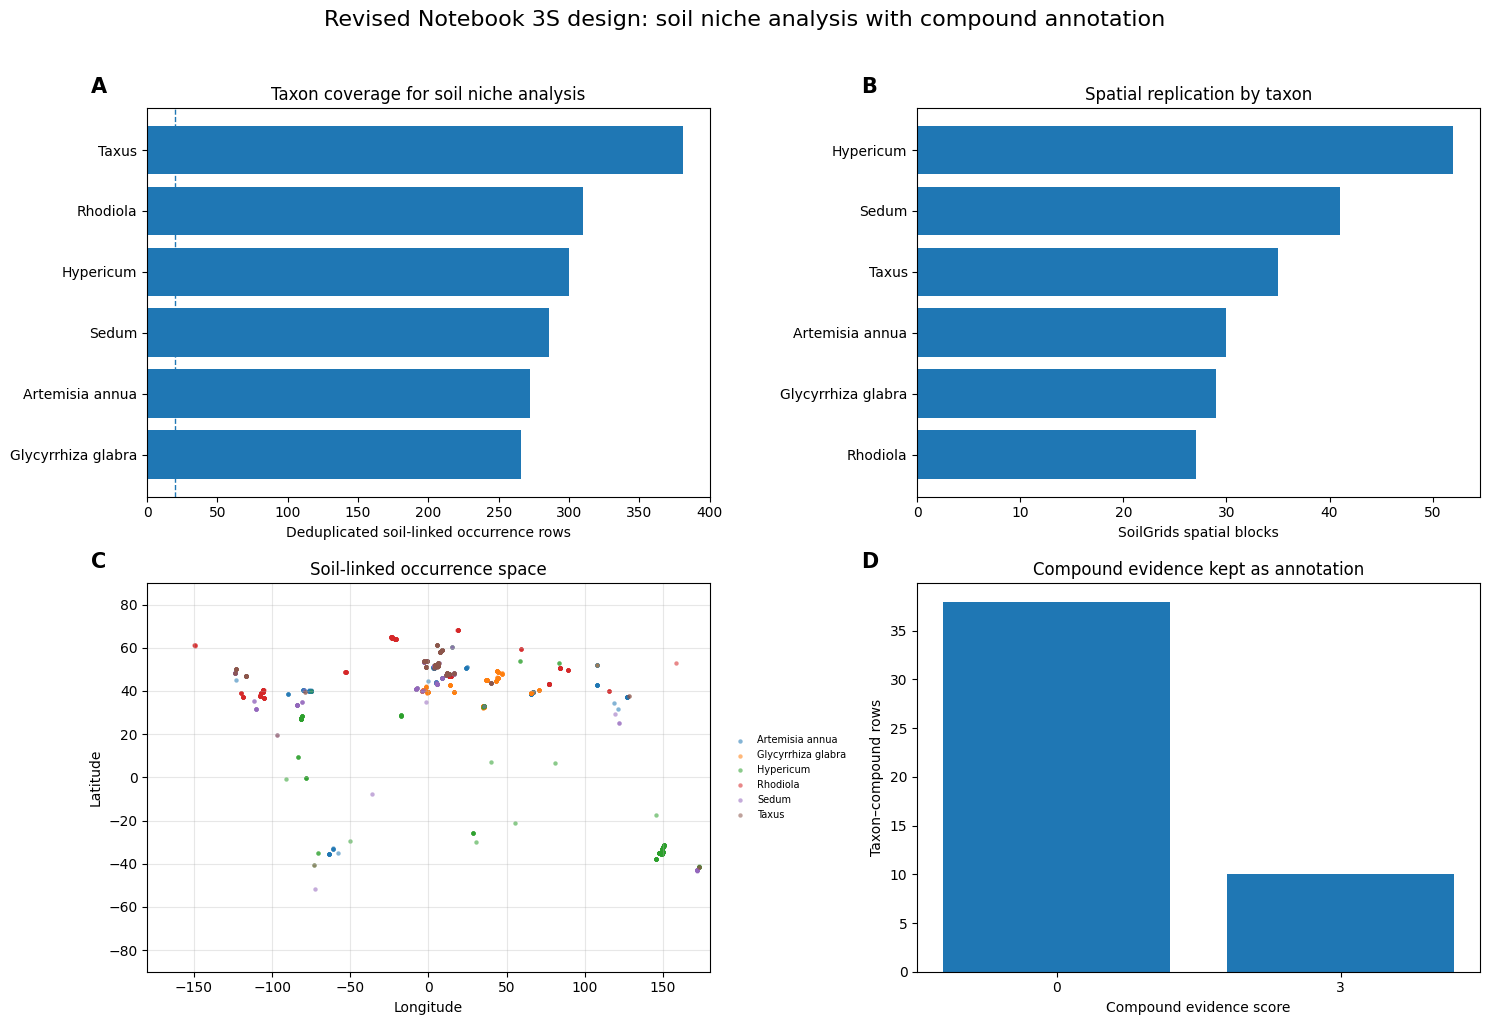

In [20]:
# ============================================================
# 6. Figure 1: revised study design and QC
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

# A: soil occurrence coverage
ax = axes[0]
plot_df = taxon_coverage_qc_df.sort_values("n_soil_occurrences")
ax.barh(plot_df["input_taxon"], plot_df["n_soil_occurrences"])
ax.axvline(CONFIG["min_taxon_occurrences_for_classification"], linestyle="--", linewidth=1)
ax.set_xlabel("Deduplicated soil-linked occurrence rows")
ax.set_title("Taxon coverage for soil niche analysis")
add_panel_label(ax, "A")

# B: spatial block coverage
ax = axes[1]
plot_df = taxon_coverage_qc_df.sort_values("n_spatial_blocks")
ax.barh(plot_df["input_taxon"], plot_df["n_spatial_blocks"])
ax.set_xlabel("SoilGrids spatial blocks")
ax.set_title("Spatial replication by taxon")
add_panel_label(ax, "B")

# C: occurrence map
ax = axes[2]
for taxon, sub in occurrence_soil_df.groupby("input_taxon"):
    ax.scatter(
        pd.to_numeric(sub.get("decimal_longitude", sub.get("block_centroid_longitude")), errors="coerce"),
        pd.to_numeric(sub.get("decimal_latitude", sub.get("block_centroid_latitude")), errors="coerce"),
        s=10, alpha=0.55, linewidths=0, label=taxon
    )
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Soil-linked occurrence space")
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
add_panel_label(ax, "C")

# D: compound annotation target distribution
ax = axes[3]
if CONFIG["ordinal_compound_target_col"] in compound_annotation_df.columns:
    counts = compound_annotation_df[CONFIG["ordinal_compound_target_col"]].value_counts().sort_index()
    ax.bar([str(x) for x in counts.index], counts.values)
    ax.set_xlabel("Compound evidence score")
    ax.set_ylabel("Taxon–compound rows")
else:
    ax.text(0.5, 0.5, "No compound evidence target", ha="center", va="center")
ax.set_title("Compound evidence kept as annotation")
add_panel_label(ax, "D")

fig.suptitle("Revised Notebook 3S design: soil niche analysis with compound annotation", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure1_soil_niche_revised_design_qc")
plt.show()

## 3. Soil niche feature matrix, PCA, and taxon centroids

This is the main publishable analysis.

It asks whether the sampled medicinal taxa occupy different SoilGrids-derived soil niche space.

In [21]:
# ============================================================
# 7. Soil niche PCA
# ============================================================

X_occ_raw = occurrence_soil_df[soil_feature_cols].copy()
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_occ = imputer.fit_transform(X_occ_raw)
X_occ = scaler.fit_transform(X_occ)

n_components = min(5, X_occ.shape[1], X_occ.shape[0])
pca = PCA(n_components=n_components, random_state=CONFIG["random_seed"])
scores = pca.fit_transform(X_occ)

pca_scores_df = occurrence_soil_df[
    [c for c in ["taxon_id", "input_taxon", "spatial_block_id", "gbif_key", "decimal_latitude", "decimal_longitude"] if c in occurrence_soil_df.columns]
].copy()

for i in range(n_components):
    pca_scores_df[f"PC{i+1}"] = scores[:, i]

pca_loadings_df = pd.DataFrame(
    pca.components_.T,
    index=soil_feature_cols,
    columns=[f"PC{i+1}" for i in range(n_components)]
).reset_index().rename(columns={"index": "soil_feature"})

pca_explained_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

taxon_centroids_df = (
    pca_scores_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        PC1_mean=("PC1", "mean"),
        PC2_mean=("PC2", "mean"),
        PC1_sd=("PC1", "std"),
        PC2_sd=("PC2", "std"),
        n_points=("PC1", "size"),
    )
)

write_table(pca_scores_df, DIRS["derived"] / "soil_niche_pca_scores_by_occurrence")
write_table(pca_loadings_df, DIRS["derived"] / "soil_niche_pca_loadings")
write_table(pca_explained_df, DIRS["derived"] / "soil_niche_pca_explained_variance")
write_table(taxon_centroids_df, DIRS["derived"] / "soil_niche_taxon_centroids_pca")

display(pca_explained_df)
display(pca_loadings_df.head())

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.457997,0.457997
1,PC2,0.233250,0.691247
2,PC3,0.110524,0.801771
3,PC4,0.060366,0.862137
4,PC5,0.052942,0.915080


,soil_feature,PC1,PC2,PC3,PC4,PC5
0,soil_cec__0_5cm__mean,0.039651,0.356358,0.068964,-0.134096,-0.120091
1,soil_cec__15_30cm__mean,-0.107455,0.269740,0.388717,-0.059473,-0.192792
2,soil_cec__5_15cm__mean,-0.065259,0.331896,0.314816,-0.034618,-0.240932
3,soil_clay__0_5cm__mean,-0.279164,0.055795,0.150955,-0.287706,0.014525
4,soil_clay__15_30cm__mean,-0.272010,0.020030,0.174234,-0.309733,-0.039870


In [22]:
# ============================================================
# 8. Soil feature correlation and taxon-level summaries
# ============================================================

soil_corr = pd.DataFrame(X_occ_raw).corr(method="spearman").fillna(0)
soil_corr.index = soil_feature_cols
soil_corr.columns = soil_feature_cols

if SCIPY_AVAILABLE and soil_corr.shape[0] > 2:
    dist = 1 - np.abs(soil_corr.values)
    np.fill_diagonal(dist, 0)
    order = leaves_list(linkage(dist, method="average"))
else:
    order = np.arange(soil_corr.shape[0])

soil_corr_ordered = soil_corr.iloc[order, order]

taxon_soil_summary_rows = []
for taxon_id, sub in occurrence_soil_df.groupby("taxon_id"):
    row = {
        "taxon_id": taxon_id,
        "input_taxon": sub["input_taxon"].iloc[0],
        "n_soil_occurrences": len(sub),
        "n_spatial_blocks": sub["spatial_block_id"].nunique() if "spatial_block_id" in sub.columns else np.nan,
    }
    for c in soil_feature_cols:
        vals = pd.to_numeric(sub[c], errors="coerce")
        row[f"{c}__mean"] = vals.mean()
        row[f"{c}__sd"] = vals.std()
        row[f"{c}__median"] = vals.median()
    taxon_soil_summary_rows.append(row)

taxon_soil_summary_df = pd.DataFrame(taxon_soil_summary_rows)

write_table(soil_corr.reset_index().rename(columns={"index": "soil_feature"}), DIRS["derived"] / "soil_feature_spearman_correlation_occurrence_level")
write_table(taxon_soil_summary_df, DIRS["derived"] / "taxon_level_soil_niche_summary")

PosixPath('/content/soilgrids_notebook3S_v2_soil_niche_outputs/derived/taxon_level_soil_niche_summary.tsv')

Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figure2_soil_niche_pca_feature_structure.png


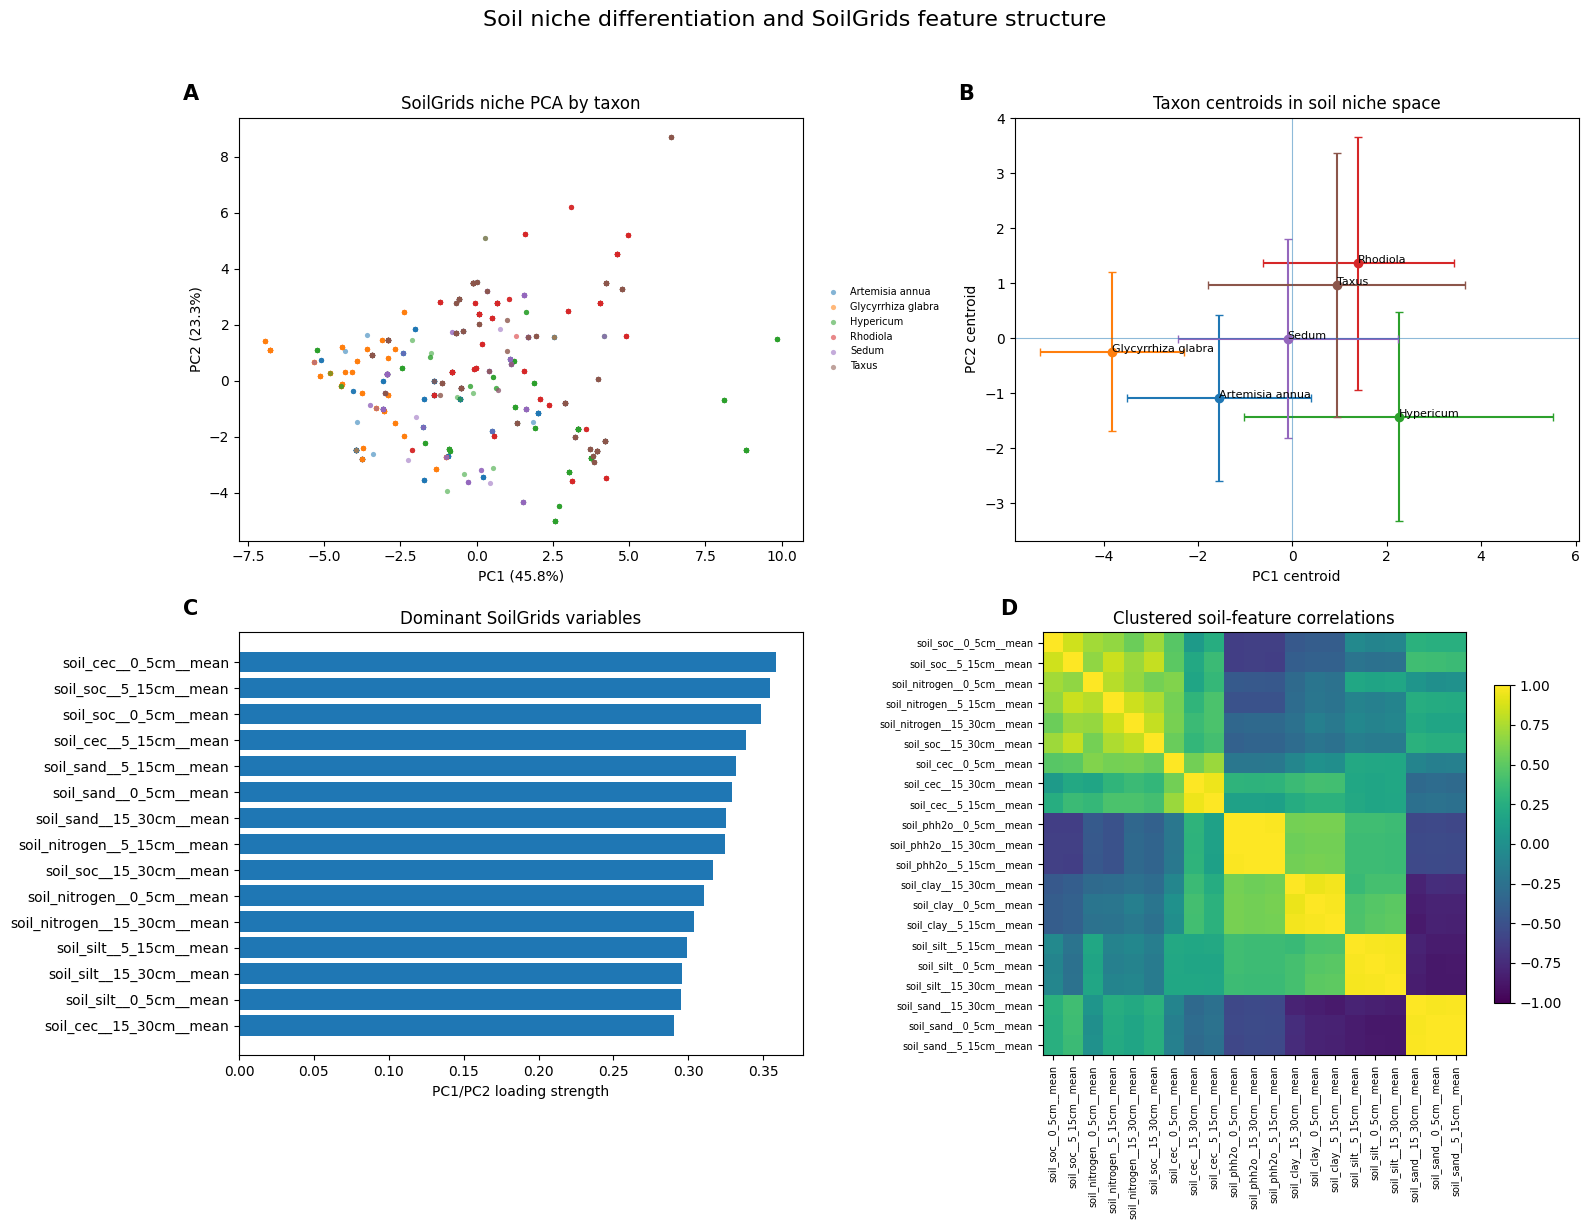

In [23]:
# ============================================================
# 9. Figure 2: soil niche PCA and feature structure
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

# A: PCA scores by taxon
ax = axes[0]
for taxon, sub in pca_scores_df.groupby("input_taxon"):
    ax.scatter(sub["PC1"], sub["PC2"], s=14, alpha=0.55, label=taxon, linewidths=0)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("SoilGrids niche PCA by taxon")
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
add_panel_label(ax, "A")

# B: Taxon centroids
ax = axes[1]
for _, r in taxon_centroids_df.iterrows():
    ax.errorbar(r["PC1_mean"], r["PC2_mean"], xerr=r["PC1_sd"], yerr=r["PC2_sd"], fmt="o", capsize=3)
    ax.text(r["PC1_mean"], r["PC2_mean"], r["input_taxon"], fontsize=8)
ax.axhline(0, linewidth=0.8, alpha=0.5)
ax.axvline(0, linewidth=0.8, alpha=0.5)
ax.set_xlabel("PC1 centroid")
ax.set_ylabel("PC2 centroid")
ax.set_title("Taxon centroids in soil niche space")
add_panel_label(ax, "B")

# C: Top PCA loadings
ax = axes[2]
loading = pca_loadings_df.copy()
loading["PC1_PC2_strength"] = np.sqrt(loading["PC1"] ** 2 + loading["PC2"] ** 2)
top_loading = loading.sort_values("PC1_PC2_strength", ascending=False).head(15).iloc[::-1]
ax.barh(top_loading["soil_feature"], top_loading["PC1_PC2_strength"])
ax.set_xlabel("PC1/PC2 loading strength")
ax.set_title("Dominant SoilGrids variables")
add_panel_label(ax, "C")

# D: Soil feature correlation heatmap
ax = axes[3]
im = ax.imshow(soil_corr_ordered.values, vmin=-1, vmax=1, interpolation="nearest")
features = soil_corr_ordered.index.tolist()
step = max(1, len(features) // 20)
ticks = list(range(0, len(features), step))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([features[i] for i in ticks], rotation=90, fontsize=7)
ax.set_yticklabels([features[i] for i in ticks], fontsize=7)
ax.set_title("Clustered soil-feature correlations")
fig.colorbar(im, ax=ax, shrink=0.75)
add_panel_label(ax, "D")

fig.suptitle("Soil niche differentiation and SoilGrids feature structure", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure2_soil_niche_pca_feature_structure")
plt.show()

## 4. Statistical tests for taxon soil niche differentiation

This section provides quantitative support for soil niche differentiation.

It uses:

1. Kruskal-Wallis tests across taxa for each soil feature.
2. Soil-niche taxon classification with spatial-group cross-validation.
3. Permutation importance for taxon differentiation.

This is not compound prediction. It tests whether taxa occupy differentiable soil niche space.

In [24]:
# ============================================================
# 10. Univariate taxon differentiation tests
# ============================================================

test_rows = []
if SCIPY_AVAILABLE:
    for feat in soil_feature_cols:
        groups = []
        taxa = []
        for taxon, sub in occurrence_soil_df.groupby("input_taxon"):
            vals = pd.to_numeric(sub[feat], errors="coerce").dropna().values
            if len(vals) >= 3:
                groups.append(vals)
                taxa.append(taxon)
        if len(groups) >= 2:
            try:
                stat, p = kruskal(*groups)
            except Exception:
                stat, p = np.nan, np.nan
        else:
            stat, p = np.nan, np.nan
        test_rows.append({
            "soil_feature": feat,
            "kruskal_statistic": stat,
            "p_value": p,
            "n_taxa_tested": len(groups),
        })

soil_taxon_tests_df = pd.DataFrame(test_rows)
if not soil_taxon_tests_df.empty:
    soil_taxon_tests_df["p_value_bh"] = np.nan
    valid = soil_taxon_tests_df["p_value"].notna()
    pvals = soil_taxon_tests_df.loc[valid, "p_value"].values
    if len(pvals):
        order = np.argsort(pvals)
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(pvals) + 1)
        bh = np.minimum(1, pvals * len(pvals) / ranks)
        soil_taxon_tests_df.loc[valid, "p_value_bh"] = bh
    soil_taxon_tests_df = soil_taxon_tests_df.sort_values("p_value")

write_table(soil_taxon_tests_df, DIRS["derived"] / "soil_feature_taxon_differentiation_kruskal_tests")
soil_taxon_tests_df.head(20)

,soil_feature,kruskal_statistic,p_value,n_taxa_tested,p_value_bh
10,soil_phh2o__15_30cm__mean,709.818319,3.700704e-151,6,7.771477e-150
9,soil_phh2o__0_5cm__mean,707.949127,9.385583e-151,6,9.854863e-150
11,soil_phh2o__5_15cm__mean,703.038164,1.082285e-149,6,7.575993e-149
20,soil_soc__5_15cm__mean,676.160535,7.005262e-144,6,3.677763e-143
18,soil_soc__0_5cm__mean,632.291646,2.127490e-134,6,8.935456e-134
8,soil_nitrogen__5_15cm__mean,605.382048,1.389863e-128,6,4.864522e-128
12,soil_sand__0_5cm__mean,575.991356,3.110062e-122,6,9.330185e-122
19,soil_soc__15_30cm__mean,560.424207,7.167150e-119,6,1.881377e-118
14,soil_sand__5_15cm__mean,558.496526,1.869393e-118,6,4.361917e-118
15,soil_silt__0_5cm__mean,551.134954,7.271648e-117,6,1.527046e-116


In [25]:
# ============================================================
# 11. Taxon classification in soil niche space
# ============================================================

# Keep taxa with adequate observations.
eligible_taxa = taxon_coverage_qc_df.loc[
    taxon_coverage_qc_df["suitable_for_taxon_niche_classification"],
    "taxon_id"
].tolist()

classification_df = occurrence_soil_df[occurrence_soil_df["taxon_id"].isin(eligible_taxa)].copy()

if len(classification_df["taxon_id"].unique()) < 2:
    raise RuntimeError("Not enough taxa for soil niche classification.")

X_taxon = classification_df[soil_feature_cols].copy()
y_taxon_label = classification_df["taxon_id"].astype(str).values

label_encoder = LabelEncoder()
y_taxon = label_encoder.fit_transform(y_taxon_label)

# Spatial groups reduce over-optimistic validation from nearby points.
if "spatial_block_id" in classification_df.columns and classification_df["spatial_block_id"].nunique() >= CONFIG["n_group_folds"]:
    groups = classification_df["spatial_block_id"].astype(str).values
    cv = GroupKFold(n_splits=min(CONFIG["n_group_folds"], classification_df["spatial_block_id"].nunique()))
    cv_name = "spatial_block_group_kfold"
else:
    groups = classification_df["taxon_id"].astype(str).values
    cv = GroupKFold(n_splits=min(CONFIG["n_group_folds"], classification_df["taxon_id"].nunique()))
    cv_name = "taxon_group_kfold_fallback"

models = {
    "dummy_most_frequent": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "logistic_multinomial": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", multi_class="auto", random_state=CONFIG["random_seed"])),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight="balanced", random_state=CONFIG["random_seed"])),
    ]),
    "gradient_boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=CONFIG["random_seed"])),
    ]),
}

taxon_cv_rows = []
taxon_pred_rows = []

for model_name, model in models.items():
    fold_id = 0
    for train_idx, test_idx in cv.split(X_taxon, y_taxon, groups=groups):
        y_train, y_test = y_taxon[train_idx], y_taxon[test_idx]
        if len(np.unique(y_train)) < 2:
            continue
        m = clone(model)
        try:
            m.fit(X_taxon.iloc[train_idx], y_train)
            pred = m.predict(X_taxon.iloc[test_idx])
            taxon_cv_rows.append({
                "model": model_name,
                "cv_scheme": cv_name,
                "fold": fold_id,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "accuracy": accuracy_score(y_test, pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
            })
            for ix, yy, pp in zip(test_idx, y_test, pred):
                taxon_pred_rows.append({
                    "model": model_name,
                    "cv_scheme": cv_name,
                    "fold": fold_id,
                    "row_index": int(classification_df.index[ix]),
                    "true_taxon_id": label_encoder.inverse_transform([yy])[0],
                    "pred_taxon_id": label_encoder.inverse_transform([pp])[0],
                    "correct": int(yy == pp),
                })
        except Exception as e:
            taxon_cv_rows.append({
                "model": model_name,
                "cv_scheme": cv_name,
                "fold": fold_id,
                "status": f"error: {e}",
                "n_train": len(train_idx),
                "n_test": len(test_idx),
            })
        fold_id += 1

taxon_cv_df = pd.DataFrame(taxon_cv_rows)
taxon_predictions_df = pd.DataFrame(taxon_pred_rows)

taxon_cv_summary_df = (
    taxon_cv_df
    .groupby(["model", "cv_scheme"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sd=("macro_f1", "std"),
        n_valid_folds=("fold", "count"),
    )
)

write_table(taxon_cv_df, DIRS["derived"] / "taxon_soil_niche_classification_fold_results")
write_table(taxon_predictions_df, DIRS["derived"] / "taxon_soil_niche_classification_predictions")
write_table(taxon_cv_summary_df, DIRS["derived"] / "taxon_soil_niche_classification_summary")

display(taxon_cv_summary_df.sort_values("balanced_accuracy_mean", ascending=False))

,model,cv_scheme,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,n_valid_folds
3,random_forest,spatial_block_group_kfold,0.514601,0.133024,0.546579,0.086679,0.466667,0.111871,5
2,logistic_multinomial,spatial_block_group_kfold,0.469421,0.046327,0.472913,0.036311,0.437831,0.045905,5
1,gradient_boosting,spatial_block_group_kfold,0.463361,0.122433,0.470561,0.074275,0.433478,0.088976,5
0,dummy_most_frequent,spatial_block_group_kfold,0.168595,0.050998,0.166667,0.000000,0.047653,0.012541,5


In [26]:
# ============================================================
# 12. Fit final taxon-niche model and compute feature importance
# ============================================================

# Select best non-dummy model.
best_candidates = taxon_cv_summary_df[~taxon_cv_summary_df["model"].eq("dummy_most_frequent")].copy()
if best_candidates.empty:
    best_candidates = taxon_cv_summary_df.copy()

best_model_name = best_candidates.sort_values("balanced_accuracy_mean", ascending=False).iloc[0]["model"]
best_taxon_model = clone(models[best_model_name])
best_taxon_model.fit(X_taxon, y_taxon)

perm = permutation_importance(
    best_taxon_model,
    X_taxon,
    y_taxon,
    n_repeats=100,
    random_state=CONFIG["random_seed"],
    scoring="balanced_accuracy",
)

taxon_importance_df = pd.DataFrame({
    "soil_feature": soil_feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

write_table(taxon_importance_df, DIRS["derived"] / "taxon_soil_niche_permutation_importance")

print("Selected taxon niche model:", best_model_name)
display(taxon_importance_df.head(20))

Selected taxon niche model: random_forest


,soil_feature,importance_mean,importance_sd
20,soil_soc__5_15cm__mean,0.005581,0.002270
17,soil_silt__5_15cm__mean,0.005536,0.002507
15,soil_silt__0_5cm__mean,0.002442,0.002083
1,soil_cec__15_30cm__mean,0.002358,0.002778
2,soil_cec__5_15cm__mean,0.002238,0.002705
5,soil_clay__5_15cm__mean,0.001877,0.001494
4,soil_clay__15_30cm__mean,0.001571,0.001124
19,soil_soc__15_30cm__mean,0.001139,0.001862
9,soil_phh2o__0_5cm__mean,0.000827,0.002584
16,soil_silt__15_30cm__mean,0.000766,0.002253


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figure3_taxon_soil_niche_differentiation.png


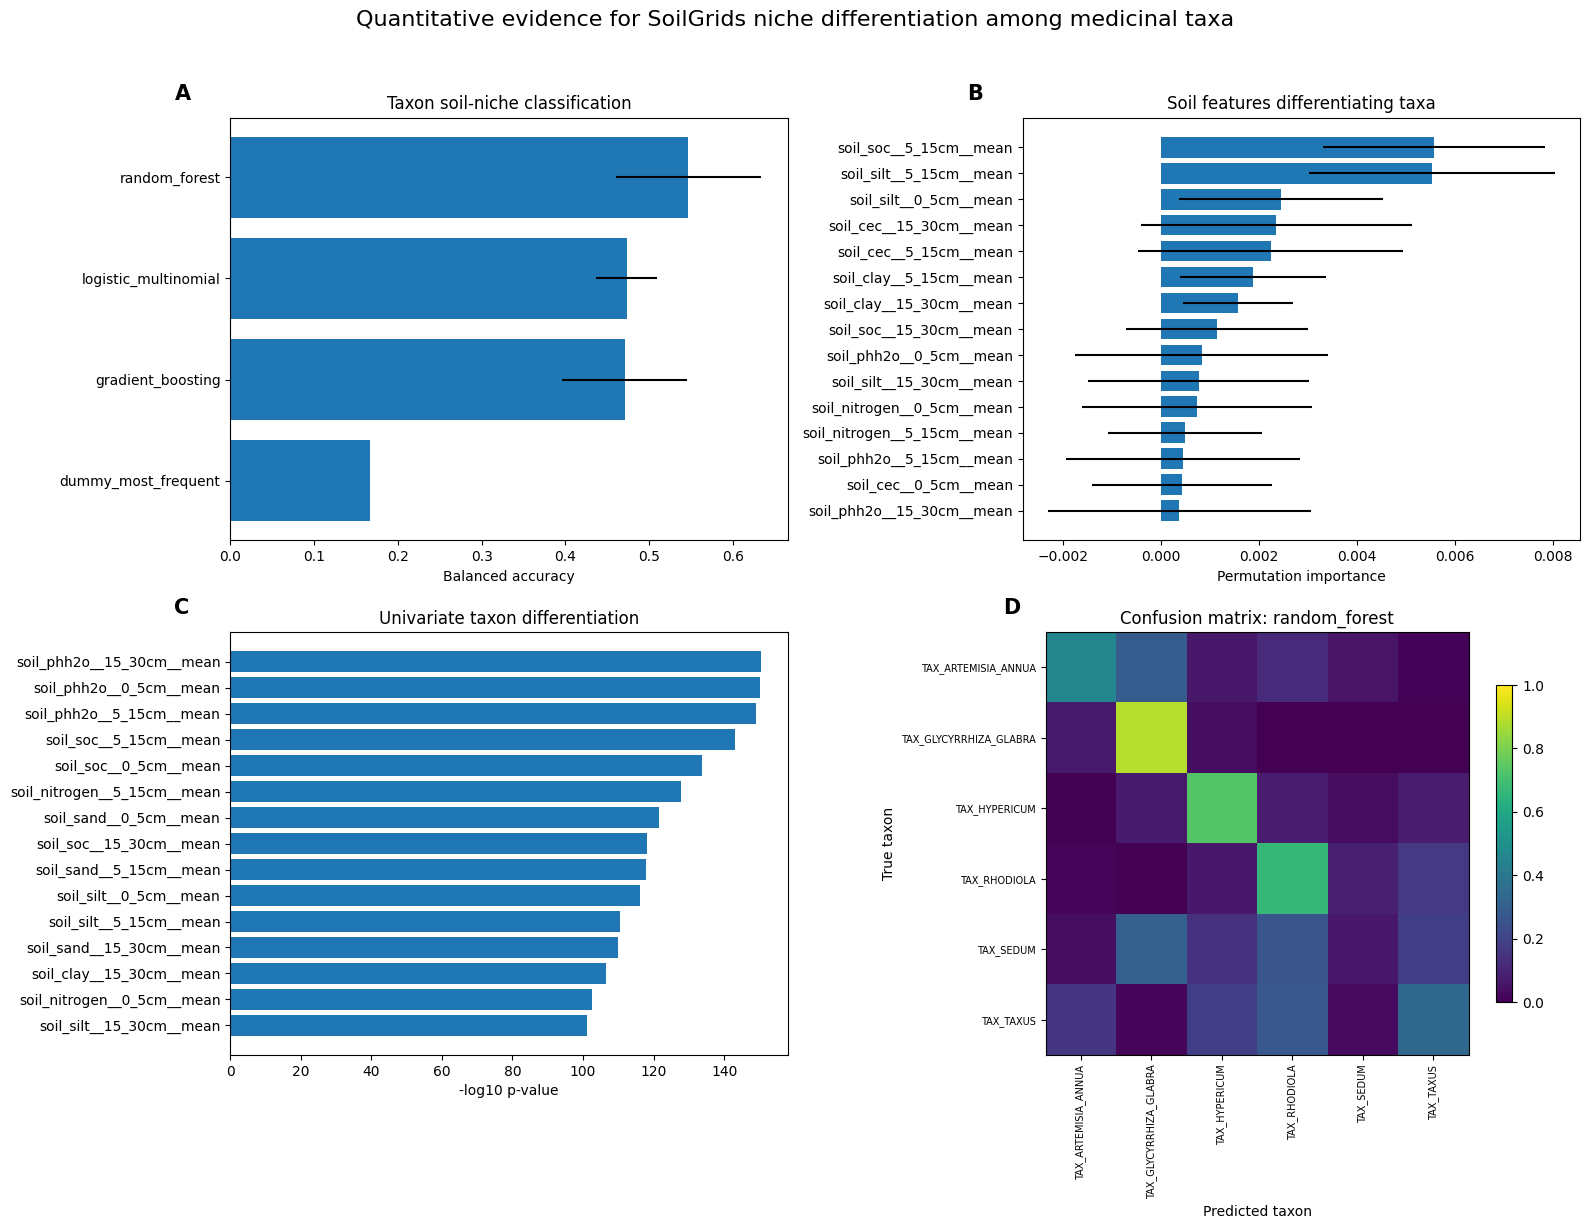

In [27]:
# ============================================================
# 13. Figure 3: taxon differentiation statistics and model results
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

# A: classification performance
ax = axes[0]
plot_df = taxon_cv_summary_df.sort_values("balanced_accuracy_mean")
ax.barh(plot_df["model"], plot_df["balanced_accuracy_mean"], xerr=plot_df["balanced_accuracy_sd"].fillna(0))
ax.set_xlabel("Balanced accuracy")
ax.set_title("Taxon soil-niche classification")
add_panel_label(ax, "A")

# B: feature importance
ax = axes[1]
top_imp = taxon_importance_df.head(15).iloc[::-1]
ax.barh(top_imp["soil_feature"], top_imp["importance_mean"], xerr=top_imp["importance_sd"])
ax.set_xlabel("Permutation importance")
ax.set_title("Soil features differentiating taxa")
add_panel_label(ax, "B")

# C: Kruskal tests
ax = axes[2]
if not soil_taxon_tests_df.empty:
    top_tests = soil_taxon_tests_df.head(15).iloc[::-1]
    neglog = -np.log10(top_tests["p_value"].replace(0, np.nan))
    ax.barh(top_tests["soil_feature"], neglog)
    ax.set_xlabel("-log10 p-value")
else:
    ax.text(0.5, 0.5, "Kruskal tests unavailable", ha="center", va="center")
ax.set_title("Univariate taxon differentiation")
add_panel_label(ax, "C")

# D: confusion matrix for best model
ax = axes[3]
pred_best = taxon_predictions_df[taxon_predictions_df["model"].eq(best_model_name)].copy()
if not pred_best.empty:
    labels = label_encoder.classes_
    cm = confusion_matrix(pred_best["true_taxon_id"], pred_best["pred_taxon_id"], labels=labels)
    # Normalize by true class.
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(cm_norm, vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Predicted taxon")
    ax.set_ylabel("True taxon")
    fig.colorbar(im, ax=ax, shrink=0.75)
else:
    ax.text(0.5, 0.5, "No predictions", ha="center", va="center")
ax.set_title(f"Confusion matrix: {best_model_name}")
add_panel_label(ax, "D")

fig.suptitle("Quantitative evidence for SoilGrids niche differentiation among medicinal taxa", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure3_taxon_soil_niche_differentiation")
plt.show()

## 5. Compound evidence as annotation, not primary ML target

This section keeps the medicinal compound information, but does not treat compound-level evidence as the main soil-only prediction target.

The heatmap links taxa to medicinal compounds for interpretation of soil niches.

Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figure4_compound_evidence_annotation_heatmap.png


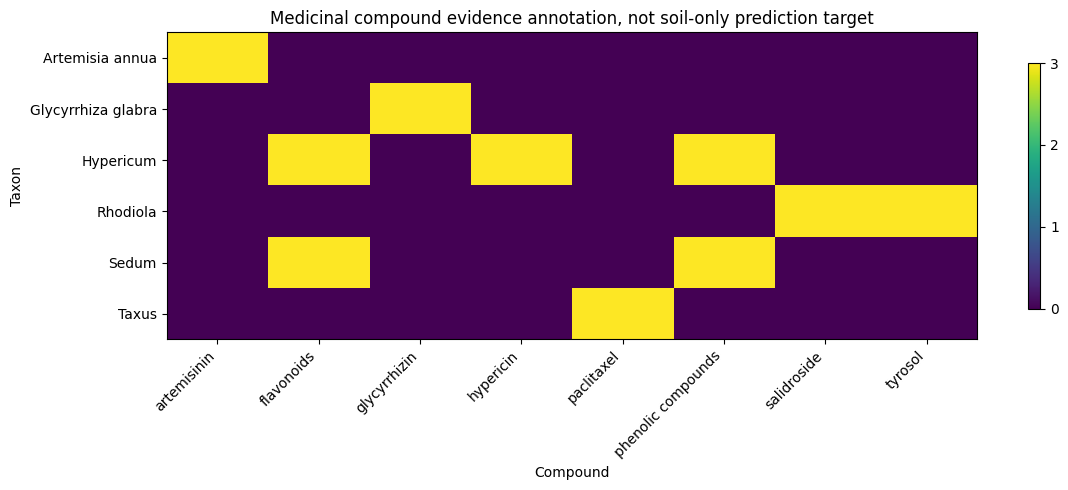

In [28]:
# ============================================================
# 14. Compound evidence annotation heatmap
# ============================================================

row_label = "scientific_name" if "scientific_name" in compound_annotation_df.columns else "input_taxon" if "input_taxon" in compound_annotation_df.columns else "taxon_id"
col_label = "compound_name" if "compound_name" in compound_annotation_df.columns else "compound_id"

if CONFIG["ordinal_compound_target_col"] in compound_annotation_df.columns:
    compound_heat = compound_annotation_df.pivot_table(
        index=row_label,
        columns=col_label,
        values=CONFIG["ordinal_compound_target_col"],
        aggfunc="max",
        fill_value=0,
    )
else:
    compound_heat = pd.DataFrame()

write_table(compound_heat.reset_index(), DIRS["derived"] / "compound_evidence_annotation_heatmap_matrix")

fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * len(compound_heat))))
if not compound_heat.empty:
    im = ax.imshow(compound_heat.values, aspect="auto", vmin=0, vmax=3)
    ax.set_yticks(range(len(compound_heat.index)))
    ax.set_yticklabels(compound_heat.index)
    ax.set_xticks(range(len(compound_heat.columns)))
    ax.set_xticklabels(compound_heat.columns, rotation=45, ha="right")
    fig.colorbar(im, ax=ax, shrink=0.8, ticks=[0, 1, 2, 3])
else:
    ax.text(0.5, 0.5, "No compound annotation matrix", ha="center", va="center")
ax.set_title("Medicinal compound evidence annotation, not soil-only prediction target")
ax.set_xlabel("Compound")
ax.set_ylabel("Taxon")
fig.tight_layout()
save_figure(fig, "figure4_compound_evidence_annotation_heatmap")
plt.show()

## 6. Negative-control compound-level ML

This section intentionally repeats the old question:

> Can soil-only predictors predict taxon–compound medicinal evidence?

Expected result: weak or chance-level performance.

This section should be reported as a **negative/control result**, not as the main model.

In [29]:
# ============================================================
# 15. Negative-control compound-level ML
# ============================================================

compound_ml_df = primary_compound_df.copy()

if CONFIG["binary_compound_target_col"] not in compound_ml_df.columns:
    if CONFIG["ordinal_compound_target_col"] in compound_ml_df.columns:
        compound_ml_df[CONFIG["binary_compound_target_col"]] = (
            pd.to_numeric(compound_ml_df[CONFIG["ordinal_compound_target_col"],], errors="coerce").fillna(0) >= 2
        ).astype(int)
    else:
        raise RuntimeError("Compound target columns unavailable.")

compound_ml_df[CONFIG["binary_compound_target_col"]] = pd.to_numeric(
    compound_ml_df[CONFIG["binary_compound_target_col"]],
    errors="coerce"
).fillna(0).astype(int)

# Use only soil summary columns from primary compound table.
compound_soil_cols = [
    c for c in compound_ml_df.columns
    if c.startswith("soil_") and pd.to_numeric(compound_ml_df[c], errors="coerce").notna().sum() >= 3
]
compound_soil_cols = [
    c for c in compound_soil_cols
    if pd.to_numeric(compound_ml_df[c], errors="coerce").nunique(dropna=True) > 1
]

if not compound_soil_cols:
    # fallback: merge taxon-level soil summary to compound table
    taxon_features = taxon_soil_summary_df.copy()
    feature_cols_merge = [c for c in taxon_features.columns if c.startswith("soil_")]
    compound_ml_df = compound_ml_df.merge(taxon_features[["taxon_id"] + feature_cols_merge], on="taxon_id", how="left")
    compound_soil_cols = [
        c for c in compound_ml_df.columns
        if c.startswith("soil_") and pd.to_numeric(compound_ml_df[c], errors="coerce").notna().sum() >= 3
    ]

X_compound = as_numeric_df(compound_ml_df, compound_soil_cols)
y_compound = compound_ml_df[CONFIG["binary_compound_target_col"]].astype(int).values

groups_compound_taxon = compound_ml_df["taxon_id"].astype(str).values if "taxon_id" in compound_ml_df.columns else np.array(["all"] * len(compound_ml_df))
groups_compound_class = compound_ml_df["compound_class"].astype(str).values if "compound_class" in compound_ml_df.columns else compound_ml_df.get("compound_id", pd.Series(["all"] * len(compound_ml_df))).astype(str).values

compound_models = {
    "dummy_most_frequent": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "logistic_l2_balanced": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear", random_state=CONFIG["random_seed"])),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight="balanced", random_state=CONFIG["random_seed"])),
    ]),
}

def evaluate_binary_grouped(X, y, groups, model_dict, scheme_name):
    rows = []
    preds = []
    unique_groups = np.unique(groups)
    if len(unique_groups) < 3 or len(np.unique(y)) < 2:
        return pd.DataFrame(), pd.DataFrame()

    cv = LeaveOneGroupOut()
    for model_name, model in model_dict.items():
        for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups)):
            if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
                rows.append({
                    "scheme": scheme_name, "model": model_name, "fold": fold,
                    "status": "skipped_single_class_train_or_test",
                    "test_group": str(np.unique(groups[te])[0]),
                    "n_train": len(tr), "n_test": len(te),
                })
                continue
            m = clone(model)
            try:
                m.fit(X.iloc[tr], y[tr])
                if hasattr(m, "predict_proba"):
                    prob = m.predict_proba(X.iloc[te])[:, 1]
                else:
                    prob = m.predict(X.iloc[te])
                pred = (prob >= 0.5).astype(int)
                rows.append({
                    "scheme": scheme_name, "model": model_name, "fold": fold,
                    "status": "ok",
                    "test_group": str(np.unique(groups[te])[0]),
                    "n_train": len(tr), "n_test": len(te),
                    "balanced_accuracy": balanced_accuracy_score(y[te], pred),
                    "accuracy": accuracy_score(y[te], pred),
                    "f1": f1_score(y[te], pred, zero_division=0),
                })
            except Exception as e:
                rows.append({
                    "scheme": scheme_name, "model": model_name, "fold": fold,
                    "status": f"error: {e}",
                    "test_group": str(np.unique(groups[te])[0]),
                    "n_train": len(tr), "n_test": len(te),
                })
    return pd.DataFrame(rows), pd.DataFrame(preds)

compound_results_taxon_df, _ = evaluate_binary_grouped(
    X_compound, y_compound, groups_compound_taxon, compound_models, "leave_one_taxon_out"
)
compound_results_class_df, _ = evaluate_binary_grouped(
    X_compound, y_compound, groups_compound_class, compound_models, "leave_one_compound_class_out"
)

compound_negative_control_df = pd.concat([compound_results_taxon_df, compound_results_class_df], ignore_index=True)

if not compound_negative_control_df.empty:
    ok = compound_negative_control_df[compound_negative_control_df["status"].eq("ok")]
    compound_negative_summary_df = (
        ok.groupby(["scheme", "model"], as_index=False)
        .agg(
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            balanced_accuracy_sd=("balanced_accuracy", "std"),
            accuracy_mean=("accuracy", "mean"),
            f1_mean=("f1", "mean"),
            n_valid_folds=("fold", "count"),
        )
    )
else:
    compound_negative_summary_df = pd.DataFrame()

write_table(pd.DataFrame({"compound_soil_feature": compound_soil_cols}), DIRS["derived"] / "negative_control_compound_soil_feature_list")
write_table(compound_negative_control_df, DIRS["derived"] / "negative_control_compound_level_soil_ml_fold_results")
write_table(compound_negative_summary_df, DIRS["derived"] / "negative_control_compound_level_soil_ml_summary")

display(compound_negative_summary_df)

,scheme,model,balanced_accuracy_mean,balanced_accuracy_sd,accuracy_mean,f1_mean,n_valid_folds
0,leave_one_compound_class_out,dummy_most_frequent,0.50000,0.000000,0.791667,0.000000,8
1,leave_one_compound_class_out,logistic_l2_balanced,0.40625,0.239326,0.500000,0.187500,8
2,leave_one_compound_class_out,random_forest,0.40625,0.239326,0.500000,0.187500,8
3,leave_one_taxon_out,dummy_most_frequent,0.50000,0.000000,0.791667,0.000000,6
4,leave_one_taxon_out,logistic_l2_balanced,0.50000,0.000000,0.416667,0.231650,6
5,leave_one_taxon_out,random_forest,0.50000,0.000000,0.666667,0.037037,6


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figure5_compound_annotation_negative_control_ml.png


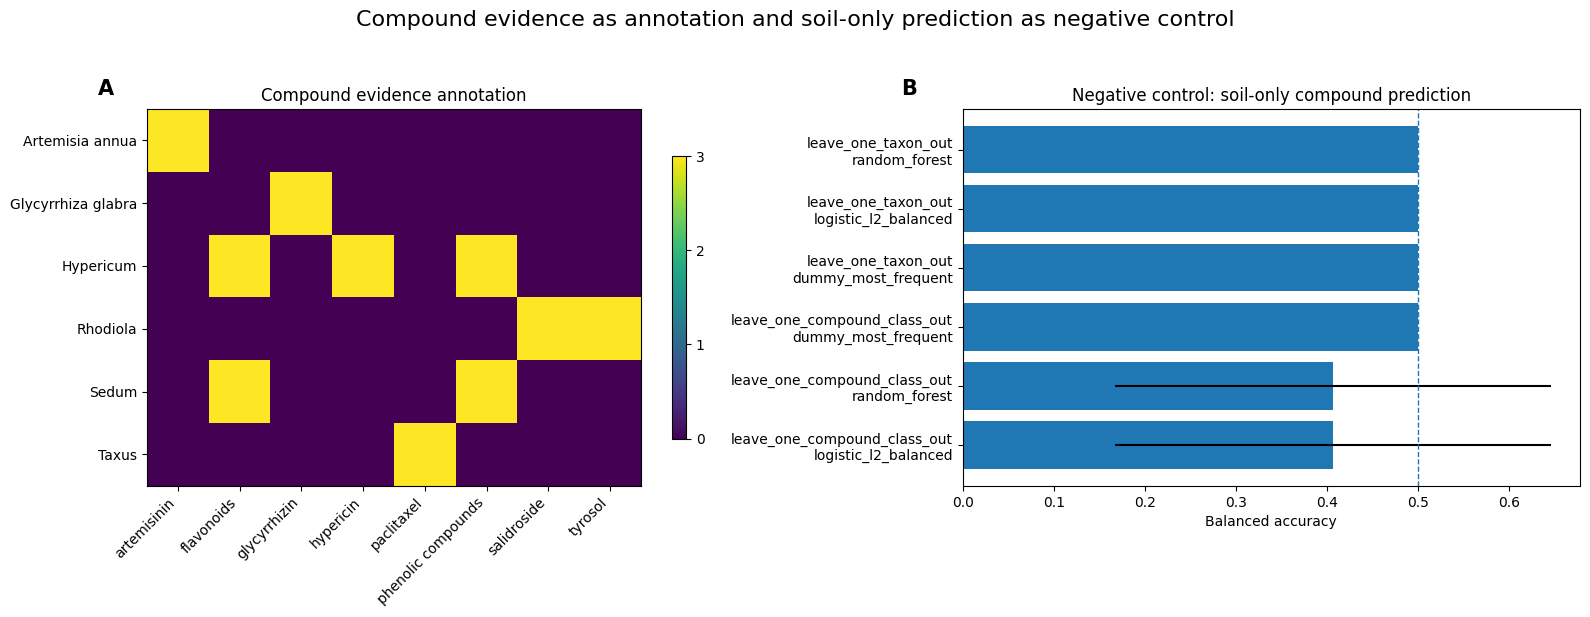

In [30]:
# ============================================================
# 16. Figure 5: negative-control compound ML panel
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A: compound evidence heatmap repeated compactly
ax = axes[0]
if not compound_heat.empty:
    im = ax.imshow(compound_heat.values, aspect="auto", vmin=0, vmax=3)
    ax.set_yticks(range(len(compound_heat.index)))
    ax.set_yticklabels(compound_heat.index)
    ax.set_xticks(range(len(compound_heat.columns)))
    ax.set_xticklabels(compound_heat.columns, rotation=45, ha="right")
    fig.colorbar(im, ax=ax, shrink=0.75, ticks=[0, 1, 2, 3])
else:
    ax.text(0.5, 0.5, "No compound matrix", ha="center", va="center")
ax.set_title("Compound evidence annotation")
add_panel_label(ax, "A")

# B: negative-control performance
ax = axes[1]
if not compound_negative_summary_df.empty:
    plot_df = compound_negative_summary_df.sort_values("balanced_accuracy_mean")
    labels = plot_df["scheme"] + "\n" + plot_df["model"]
    ax.barh(labels, plot_df["balanced_accuracy_mean"], xerr=plot_df["balanced_accuracy_sd"].fillna(0))
    ax.axvline(0.5, linestyle="--", linewidth=1)
    ax.set_xlabel("Balanced accuracy")
else:
    ax.text(0.5, 0.5, "No valid compound-level folds", ha="center", va="center")
ax.set_title("Negative control: soil-only compound prediction")
add_panel_label(ax, "B")

fig.suptitle("Compound evidence as annotation and soil-only prediction as negative control", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure5_compound_annotation_negative_control_ml")
plt.show()

## 7. Manuscript-ready outputs and interpretation

In [31]:
# ============================================================
# 17. Manuscript tables
# ============================================================

table1 = pd.DataFrame([
    {"item": "Deduplicated soil-linked occurrence rows", "value": len(occurrence_soil_df)},
    {"item": "Taxa included", "value": occurrence_soil_df["taxon_id"].nunique()},
    {"item": "Soil feature columns", "value": len(soil_feature_cols)},
    {"item": "Primary analysis", "value": "soil niche differentiation among taxa"},
    {"item": "Secondary analysis", "value": "compound-level soil-only ML negative control"},
    {"item": "Best taxon niche model", "value": best_model_name},
    {"item": "Best taxon niche balanced accuracy", "value": taxon_cv_summary_df.loc[taxon_cv_summary_df["model"].eq(best_model_name), "balanced_accuracy_mean"].iloc[0]},
])

table2 = taxon_coverage_qc_df.copy()
table3 = taxon_cv_summary_df.sort_values("balanced_accuracy_mean", ascending=False).copy()
table4 = taxon_importance_df.head(30).copy()
table5 = compound_negative_summary_df.copy()

write_table(table1, DIRS["tables"] / "table1_soil_niche_study_summary")
write_table(table2, DIRS["tables"] / "table2_taxon_soil_niche_coverage")
write_table(table3, DIRS["tables"] / "table3_taxon_soil_niche_classification")
write_table(table4, DIRS["tables"] / "table4_soil_niche_feature_importance")
write_table(table5, DIRS["tables"] / "table5_negative_control_compound_ml")

display(table1)
display(table3)
display(table4.head())
display(table5)

Parquet skipped for table1_soil_niche_study_summary: ("Could not convert 'soil niche differentiation among taxa' with type str: tried to convert to int64", 'Conversion failed for column value with type object')


,item,value
0,Deduplicated soil-linked occurrence rows,1815
1,Taxa included,6
2,Soil feature columns,21
3,Primary analysis,soil niche differentiation among taxa
4,Secondary analysis,compound-level soil-only ML negative control
5,Best taxon niche model,random_forest
6,Best taxon niche balanced accuracy,0.546579


,model,cv_scheme,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,n_valid_folds
3,random_forest,spatial_block_group_kfold,0.514601,0.133024,0.546579,0.086679,0.466667,0.111871,5
2,logistic_multinomial,spatial_block_group_kfold,0.469421,0.046327,0.472913,0.036311,0.437831,0.045905,5
1,gradient_boosting,spatial_block_group_kfold,0.463361,0.122433,0.470561,0.074275,0.433478,0.088976,5
0,dummy_most_frequent,spatial_block_group_kfold,0.168595,0.050998,0.166667,0.000000,0.047653,0.012541,5


,soil_feature,importance_mean,importance_sd
20,soil_soc__5_15cm__mean,0.005581,0.002270
17,soil_silt__5_15cm__mean,0.005536,0.002507
15,soil_silt__0_5cm__mean,0.002442,0.002083
1,soil_cec__15_30cm__mean,0.002358,0.002778
2,soil_cec__5_15cm__mean,0.002238,0.002705


,scheme,model,balanced_accuracy_mean,balanced_accuracy_sd,accuracy_mean,f1_mean,n_valid_folds
0,leave_one_compound_class_out,dummy_most_frequent,0.50000,0.000000,0.791667,0.000000,8
1,leave_one_compound_class_out,logistic_l2_balanced,0.40625,0.239326,0.500000,0.187500,8
2,leave_one_compound_class_out,random_forest,0.40625,0.239326,0.500000,0.187500,8
3,leave_one_taxon_out,dummy_most_frequent,0.50000,0.000000,0.791667,0.000000,6
4,leave_one_taxon_out,logistic_l2_balanced,0.50000,0.000000,0.416667,0.231650,6
5,leave_one_taxon_out,random_forest,0.50000,0.000000,0.666667,0.037037,6


In [32]:
# ============================================================
# 18. Final QC and interpretation report
# ============================================================

best_bal_acc = taxon_cv_summary_df.loc[
    taxon_cv_summary_df["model"].eq(best_model_name),
    "balanced_accuracy_mean"
].iloc[0]

compound_best = np.nan
if not compound_negative_summary_df.empty:
    non_dummy = compound_negative_summary_df[~compound_negative_summary_df["model"].str.contains("dummy", case=False, na=False)]
    if not non_dummy.empty:
        compound_best = non_dummy["balanced_accuracy_mean"].max()

qc_lines = [
    "# Notebook 3S v2 QC and interpretation report",
    f"Run ID: {RUN_ID}",
    "",
    "## Main conclusion",
    "This notebook treats SoilGrids data as a soil-niche layer, not as a standalone compound-prediction layer.",
    "",
    "## Main soil niche analysis",
    f"Deduplicated soil-linked occurrence rows: {len(occurrence_soil_df)}",
    f"Taxa included: {occurrence_soil_df['taxon_id'].nunique()}",
    f"Soil features: {len(soil_feature_cols)}",
    f"Best taxon soil-niche model: {best_model_name}",
    f"Best taxon soil-niche balanced accuracy: {best_bal_acc}",
    "",
    "## Compound-level negative control",
    f"Best non-dummy compound-level soil-only balanced accuracy: {compound_best}",
    "Compound-level evidence is retained as annotation, not as the primary modelling target.",
    "",
    "## Supported manuscript claim",
    "A low-cost, balanced SoilGrids workflow can characterize soil niche differentiation among medicinal plant taxa and provide ecological context for medicinal-plant prioritization.",
    "",
    "## Unsupported claims",
    "Do not claim that SoilGrids alone predicts medicinal compound accumulation.",
    "Do not claim that soil causes salidroside or other metabolites to accumulate.",
    "",
    "## Recommended manuscript framing",
    "Frame the paper as a reproducible open-data SoilGrids niche characterization and prioritization framework.",
    "Report compound-level soil-only ML as a negative-control result demonstrating the limits of soil-only predictors.",
]

qc_path = DIRS["derived"] / "notebook3S_v2_qc_and_interpretation_report.md"
qc_path.write_text("\n".join(qc_lines), encoding="utf-8")

# Lightweight run manifest
manifest_rows = []
for path in PROJECT.rglob("*"):
    if path.is_file():
        try:
            manifest_rows.append({
                "path": str(path.relative_to(PROJECT)),
                "bytes": path.stat().st_size,
                "modified_utc": dt.datetime.fromtimestamp(path.stat().st_mtime, tz=dt.timezone.utc).isoformat(timespec="seconds"),
                "run_id": RUN_ID,
            })
        except Exception as e:
            print("Skipping", path, e)

manifest_df = pd.DataFrame(manifest_rows).sort_values("path")
write_table(manifest_df, PROJECT / "run_file_manifest_fast")

print(qc_path)
display(manifest_df.head(20))

/content/soilgrids_notebook3S_v2_soil_niche_outputs/derived/notebook3S_v2_qc_and_interpretation_report.md


,path,bytes,modified_utc,run_id
56,derived/compound_evidence_annotation_heatmap_m...,6598,2026-05-15T05:41:12+00:00,20260515T053858Z
49,derived/compound_evidence_annotation_heatmap_m...,274,2026-05-15T05:41:12+00:00,20260515T053858Z
45,derived/compound_evidence_annotation_table_not...,42991,2026-05-15T05:38:58+00:00,20260515T053858Z
52,derived/compound_evidence_annotation_table_not...,42175,2026-05-15T05:38:58+00:00,20260515T053858Z
20,derived/negative_control_compound_level_soil_m...,6776,2026-05-15T05:41:17+00:00,20260515T053858Z
36,derived/negative_control_compound_level_soil_m...,3937,2026-05-15T05:41:17+00:00,20260515T053858Z
50,derived/negative_control_compound_level_soil_m...,5059,2026-05-15T05:41:17+00:00,20260515T053858Z
34,derived/negative_control_compound_level_soil_m...,595,2026-05-15T05:41:17+00:00,20260515T053858Z
43,derived/negative_control_compound_soil_feature...,1736,2026-05-15T05:41:17+00:00,20260515T053858Z
47,derived/negative_control_compound_soil_feature...,1258,2026-05-15T05:41:17+00:00,20260515T053858Z


In [35]:
# ============================================================
# Additional publication-style SoilGrids figures
# Helper setup
# Insert after the negative-control compound ML section
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except Exception:
    NETWORKX_AVAILABLE = False
    print("networkx is not available. Graph figure will be skipped.")

def _safe_numeric(df, cols):
    out = pd.DataFrame(index=df.index)
    for c in cols:
        out[c] = pd.to_numeric(df[c], errors="coerce")
    return out

def _zscore_df(df):
    numeric = df.apply(pd.to_numeric, errors="coerce")
    return (numeric - numeric.mean(axis=0)) / numeric.std(axis=0).replace(0, np.nan)

def _short_feature_name(x):
    x = str(x)
    x = x.replace("soil_", "")
    x = x.replace("__mean", "")
    x = x.replace("__median", "")
    x = x.replace("__sd", "")
    x = x.replace("_", "-")
    return x

def _save_pubfig(fig, name):
    png = DIRS["figures"] / f"{name}.png"
    fig.savefig(png, dpi=CONFIG.get("figure_dpi", 300), bbox_inches="tight")
    if CONFIG.get("save_pdf", True):
        pdf = DIRS["figures"] / f"{name}.pdf"
        fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)

def _panel(ax, label):
    ax.text(
        -0.10, 1.08, label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top"
    )

# Safety checks
required_objects = ["occurrence_soil_df", "compound_annotation_df", "soil_feature_cols"]
missing = [x for x in required_objects if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects from Notebook 3S v2: {missing}")

soil_feature_cols = [
    c for c in soil_feature_cols
    if c in occurrence_soil_df.columns
    and pd.to_numeric(occurrence_soil_df[c], errors="coerce").notna().sum() >= 3
    and pd.to_numeric(occurrence_soil_df[c], errors="coerce").nunique(dropna=True) > 1
]

print("Soil feature columns available:", len(soil_feature_cols))
print("Occurrence-soil rows:", len(occurrence_soil_df))
print("Taxa:", occurrence_soil_df["taxon_id"].nunique())

Soil feature columns available: 21
Occurrence-soil rows: 1815
Taxa: 6


In [36]:
# ============================================================
# Additional publication-style SoilGrids figures
# Helper setup
# Insert after the negative-control compound ML section
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except Exception:
    NETWORKX_AVAILABLE = False
    print("networkx is not available. Graph figure will be skipped.")

def _safe_numeric(df, cols):
    out = pd.DataFrame(index=df.index)
    for c in cols:
        out[c] = pd.to_numeric(df[c], errors="coerce")
    return out

def _zscore_df(df):
    numeric = df.apply(pd.to_numeric, errors="coerce")
    return (numeric - numeric.mean(axis=0)) / numeric.std(axis=0).replace(0, np.nan)

def _short_feature_name(x):
    x = str(x)
    x = x.replace("soil_", "")
    x = x.replace("__mean", "")
    x = x.replace("__median", "")
    x = x.replace("__sd", "")
    x = x.replace("_", "-")
    return x

def _save_pubfig(fig, name):
    png = DIRS["figures"] / f"{name}.png"
    fig.savefig(png, dpi=CONFIG.get("figure_dpi", 300), bbox_inches="tight")
    if CONFIG.get("save_pdf", True):
        pdf = DIRS["figures"] / f"{name}.pdf"
        fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)

def _panel(ax, label):
    ax.text(
        -0.10, 1.08, label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top"
    )

# Safety checks
required_objects = ["occurrence_soil_df", "compound_annotation_df", "soil_feature_cols"]
missing = [x for x in required_objects if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects from Notebook 3S v2: {missing}")

soil_feature_cols = [
    c for c in soil_feature_cols
    if c in occurrence_soil_df.columns
    and pd.to_numeric(occurrence_soil_df[c], errors="coerce").notna().sum() >= 3
    and pd.to_numeric(occurrence_soil_df[c], errors="coerce").nunique(dropna=True) > 1
]

print("Soil feature columns available:", len(soil_feature_cols))
print("Occurrence-soil rows:", len(occurrence_soil_df))
print("Taxa:", occurrence_soil_df["taxon_id"].nunique())

Soil feature columns available: 21
Occurrence-soil rows: 1815
Taxa: 6


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figureS2_soil_niche_profile_by_taxon.png


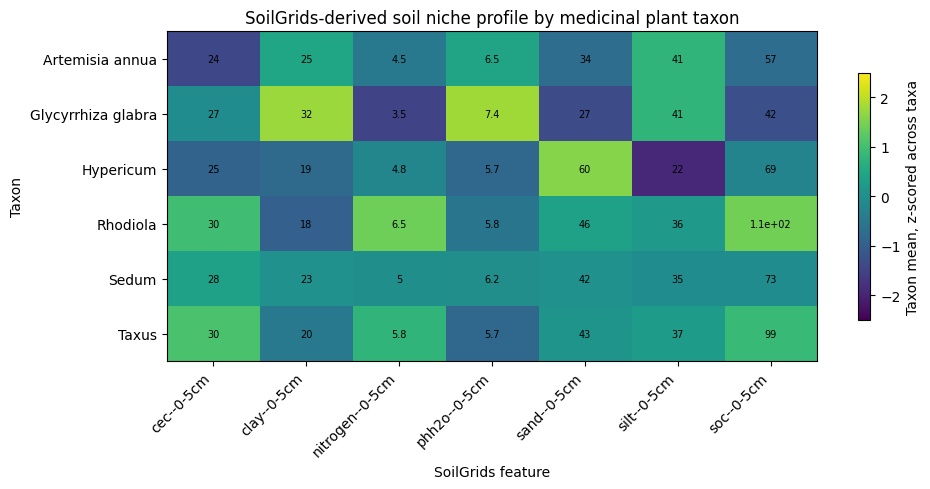

PosixPath('/content/soilgrids_notebook3S_v2_soil_niche_outputs/derived/soil_niche_profile_by_taxon_zscores.tsv')

In [37]:
# ============================================================
# Figure S2 — Soil niche profile by taxon
# Soil analogue of "pathway potential by taxon"
# ============================================================

# Prefer interpretable topsoil mean features.
preferred_features = [
    c for c in soil_feature_cols
    if any(p in c for p in ["phh2o", "soc", "nitrogen", "clay", "sand", "silt", "cec"])
    and "0_5cm" in c
]

# If naming is 0-5cm or other format, fallback to all mean features.
if len(preferred_features) < 4:
    preferred_features = [
        c for c in soil_feature_cols
        if any(p in c for p in ["phh2o", "soc", "nitrogen", "clay", "sand", "silt", "cec"])
    ]

# Keep manageable number.
preferred_features = preferred_features[:14]

taxon_soil_profile = (
    occurrence_soil_df
    .groupby("input_taxon")[preferred_features]
    .mean()
)

taxon_soil_profile_z = _zscore_df(taxon_soil_profile)

fig, ax = plt.subplots(figsize=(max(10, 0.75 * len(preferred_features)), max(5, 0.55 * len(taxon_soil_profile_z))))

im = ax.imshow(taxon_soil_profile_z.values, aspect="auto", vmin=-2.5, vmax=2.5)

ax.set_yticks(range(len(taxon_soil_profile_z.index)))
ax.set_yticklabels(taxon_soil_profile_z.index)

ax.set_xticks(range(len(taxon_soil_profile_z.columns)))
ax.set_xticklabels(
    [_short_feature_name(c) for c in taxon_soil_profile_z.columns],
    rotation=45,
    ha="right"
)

# Annotate raw means, not z-scores.
for i in range(taxon_soil_profile.shape[0]):
    for j in range(taxon_soil_profile.shape[1]):
        val = taxon_soil_profile.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2g}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, shrink=0.75, label="Taxon mean, z-scored across taxa")
ax.set_title("SoilGrids-derived soil niche profile by medicinal plant taxon")
ax.set_xlabel("SoilGrids feature")
ax.set_ylabel("Taxon")

fig.tight_layout()
_save_pubfig(fig, "figureS2_soil_niche_profile_by_taxon")
plt.show()

write_table(
    taxon_soil_profile.reset_index(),
    DIRS["derived"] / "soil_niche_profile_by_taxon_raw_means"
)

write_table(
    taxon_soil_profile_z.reset_index(),
    DIRS["derived"] / "soil_niche_profile_by_taxon_zscores"
)

Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figureS3_block_level_soilgrids_pca.png


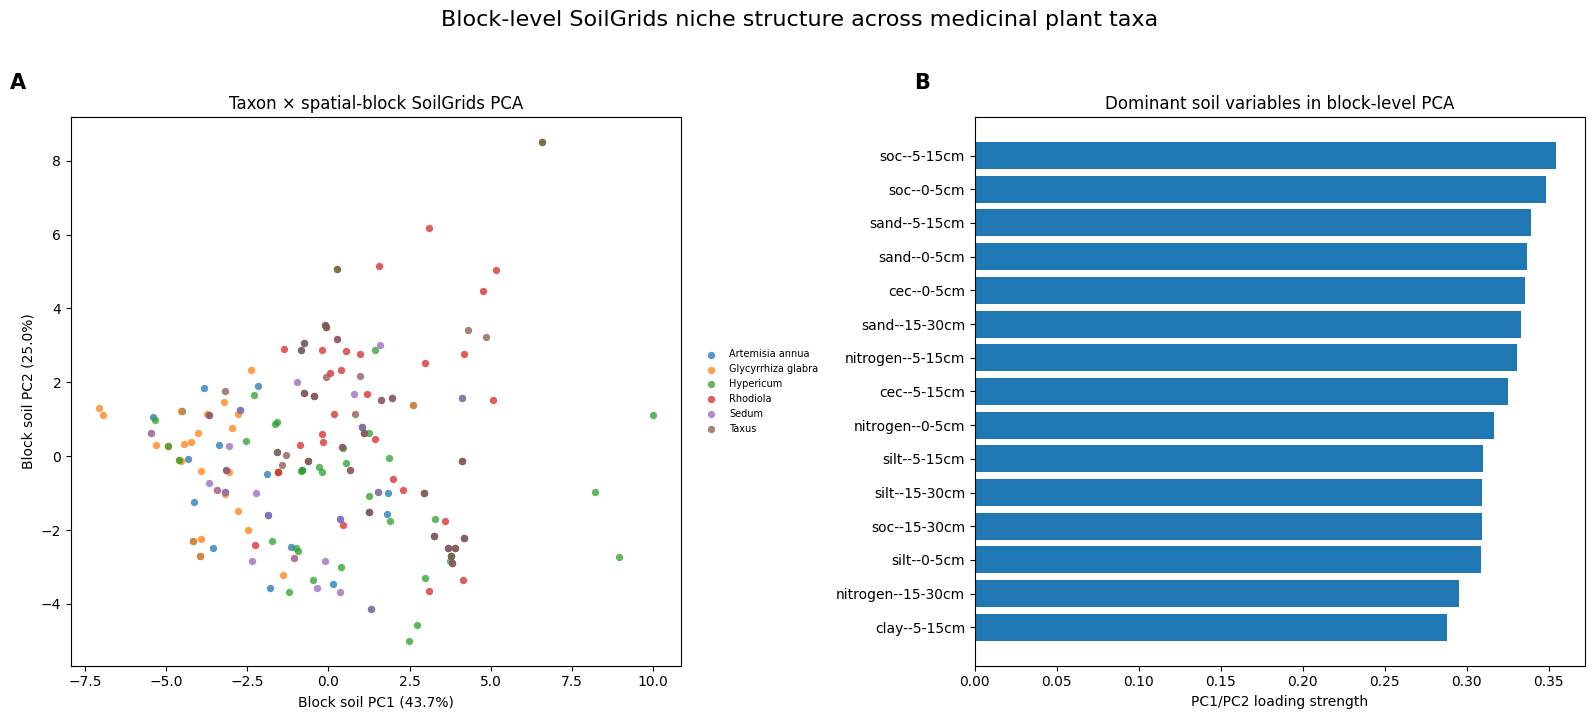

PosixPath('/content/soilgrids_notebook3S_v2_soil_niche_outputs/derived/block_level_soil_pca_explained_variance.tsv')

In [39]:
# ============================================================
# Figure S3 — Taxon × spatial-block SoilGrids PCA
# Corrected block-level analogue of occurrence-level environmental PCA
# ============================================================

# Build taxon × spatial-block table.
block_keys = ["taxon_id", "input_taxon", "spatial_block_id"]
block_keys = [c for c in block_keys if c in occurrence_soil_df.columns]

# Ensure coordinate columns are numeric for mean aggregation
for col in ["decimal_latitude", "decimal_longitude"]:
    if col in occurrence_soil_df.columns:
        occurrence_soil_df[col] = pd.to_numeric(occurrence_soil_df[col], errors="coerce")

taxon_block_soil_df = (
    occurrence_soil_df
    .groupby(block_keys, as_index=False)
    .agg(
        n_occurrences=("taxon_id", "size"),
        decimal_latitude=("decimal_latitude", "mean") if "decimal_latitude" in occurrence_soil_df.columns else ("taxon_id", "size"),
        decimal_longitude=("decimal_longitude", "mean") if "decimal_longitude" in occurrence_soil_df.columns else ("taxon_id", "size"),
        **{c: (c, "mean") for c in soil_feature_cols}
    )
)

X_block = taxon_block_soil_df[soil_feature_cols].apply(pd.to_numeric, errors="coerce")

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_block_imp = SimpleImputer(strategy="median").fit_transform(X_block)
X_block_scaled = StandardScaler().fit_transform(X_block_imp)

n_components = min(5, X_block_scaled.shape[0], X_block_scaled.shape[1])
pca_block = PCA(n_components=n_components, random_state=CONFIG.get("random_seed", 42))
block_scores = pca_block.fit_transform(X_block_scaled)

block_pca_scores_df = taxon_block_soil_df[block_keys + ["n_occurrences"]].copy()
for i in range(n_components):
    block_pca_scores_df[f"PC{i+1}"] = block_scores[:, i]

block_pca_loadings_df = pd.DataFrame(
    pca_block.components_.T,
    index=soil_feature_cols,
    columns=[f"PC{i+1}" for i in range(n_components)]
).reset_index().rename(columns={"index": "soil_feature"})

block_pca_explained_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_ratio": pca_block.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_block.explained_variance_ratio_),
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# A: block-level PCA scatter
ax = axes[0]
for taxon, sub in block_pca_scores_df.groupby("input_taxon"):
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=28,
        alpha=0.75,
        linewidths=0,
        label=taxon
    )

ax.set_xlabel(f"Block soil PC1 ({pca_block.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"Block soil PC2 ({pca_block.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("Taxon × spatial-block SoilGrids PCA")
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
_panel(ax, "A")

# B: top loadings
ax = axes[1]
load = block_pca_loadings_df.copy()
load["PC1_PC2_strength"] = np.sqrt(load["PC1"] ** 2 + load["PC2"] ** 2)
top_load = load.sort_values("PC1_PC2_strength", ascending=False).head(15).iloc[::-1]

ax.barh(
    [_short_feature_name(x) for x in top_load["soil_feature"]],
    top_load["PC1_PC2_strength"]
)
ax.set_xlabel("PC1/PC2 loading strength")
ax.set_title("Dominant soil variables in block-level PCA")
_panel(ax, "B")

fig.suptitle("Block-level SoilGrids niche structure across medicinal plant taxa", fontsize=16, y=1.02)
fig.tight_layout()
_save_pubfig(fig, "figureS3_block_level_soilgrids_pca")
plt.show()

write_table(
    taxon_block_soil_df,
    DIRS["derived"] / "taxon_spatial_block_soil_table"
)

write_table(
    block_pca_scores_df,
    DIRS["derived"] / "block_level_soil_pca_scores"
)

write_table(
    block_pca_loadings_df,
    DIRS["derived"] / "block_level_soil_pca_loadings"
)

write_table(
    block_pca_explained_df,
    DIRS["derived"] / "block_level_soil_pca_explained_variance"
)


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figureS4_clustered_soilgrids_feature_correlation.png


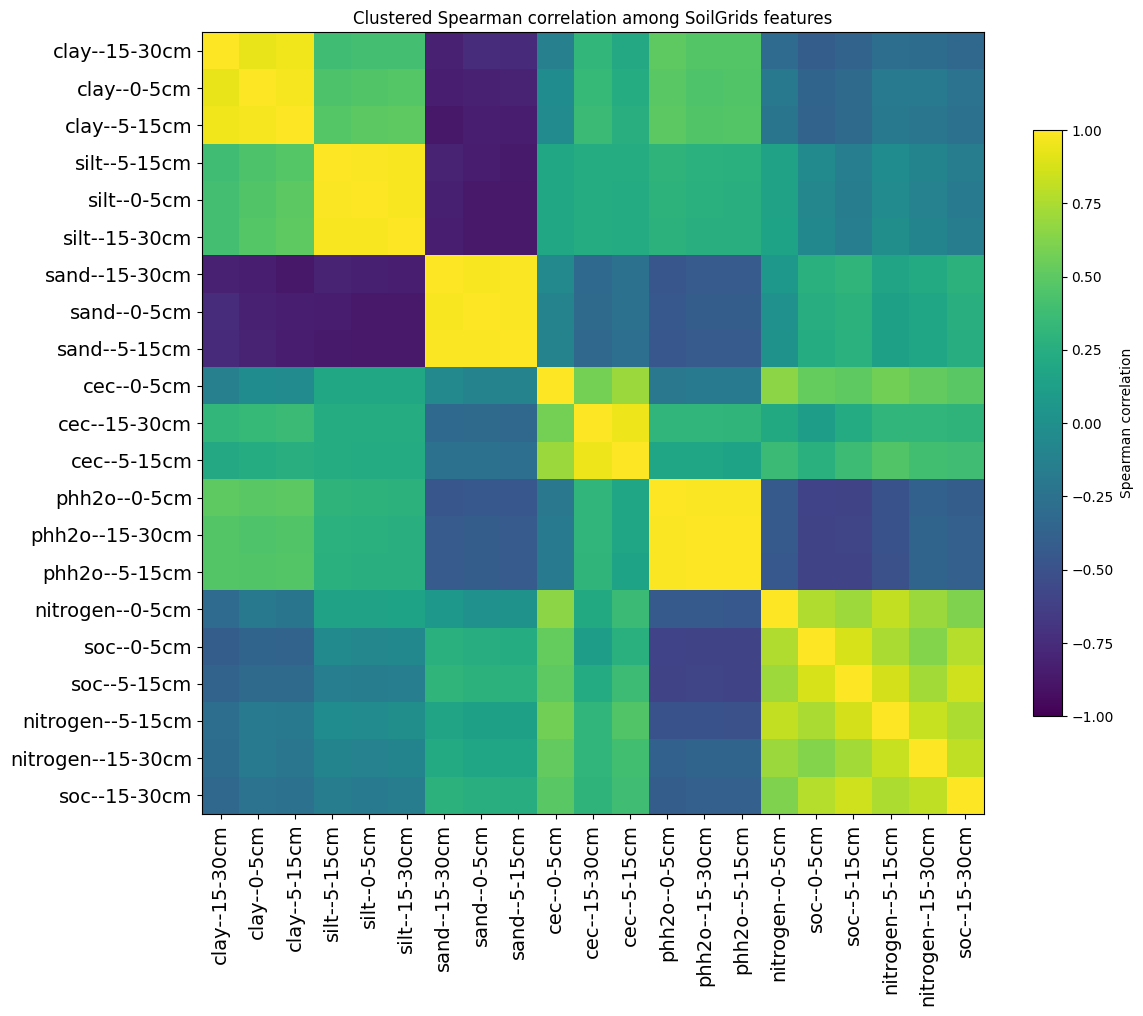

PosixPath('/content/soilgrids_notebook3S_v2_soil_niche_outputs/derived/block_level_soil_feature_spearman_correlation.tsv')

In [41]:
# ============================================================
# Figure S4 — Clustered Spearman correlation among SoilGrids features
# Soil analogue of engineered-feature correlation heatmap
# ============================================================

from scipy.cluster.hierarchy import linkage, leaves_list

soil_corr_input = taxon_block_soil_df[soil_feature_cols].apply(pd.to_numeric, errors="coerce")
soil_corr_input = soil_corr_input.loc[:, soil_corr_input.nunique(dropna=True) > 1]

soil_corr = soil_corr_input.corr(method="spearman").fillna(0)

if soil_corr.shape[0] > 2:
    dist = 1 - np.abs(soil_corr.values)
    np.fill_diagonal(dist, 0)
    order = leaves_list(linkage(dist, method="average"))
else:
    order = np.arange(soil_corr.shape[0])

soil_corr_ordered = soil_corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(soil_corr_ordered.values, vmin=-1, vmax=1, interpolation="nearest")

features = soil_corr_ordered.index.tolist()
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))

ax.set_xticklabels([_short_feature_name(f) for f in features], rotation=90, fontsize=14)
ax.set_yticklabels([_short_feature_name(f) for f in features], fontsize=14)

fig.colorbar(im, ax=ax, shrink=0.75, label="Spearman correlation")
ax.set_title("Clustered Spearman correlation among SoilGrids features")

fig.tight_layout()
_save_pubfig(fig, "figureS4_clustered_soilgrids_feature_correlation")
plt.show()

write_table(
    soil_corr.reset_index().rename(columns={"index": "soil_feature"}),
    DIRS["derived"] / "block_level_soil_feature_spearman_correlation"
)


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figureS5_integrated_taxon_compound_soilgrids_graph.png


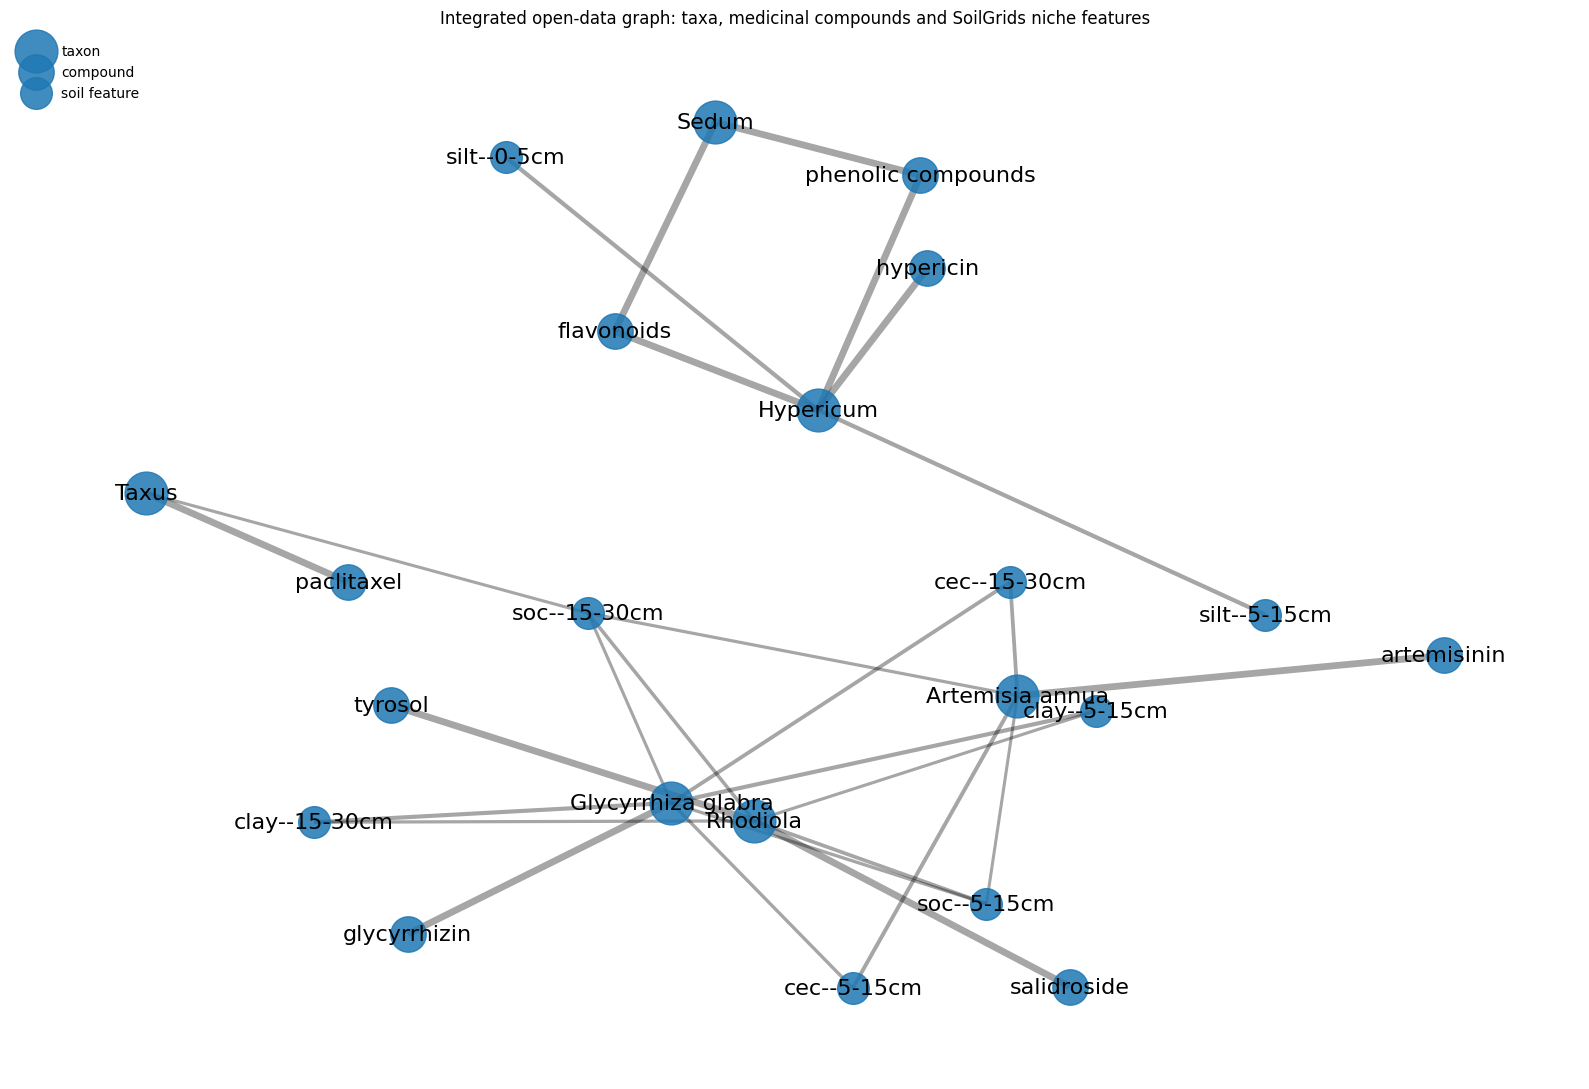

In [43]:
# ============================================================
# Figure S5 — Integrated taxon–compound–soil feature graph
# SoilGrids analogue of evidence graph
# ============================================================

if not NETWORKX_AVAILABLE:
    print("networkx is not installed; skipping graph figure.")
else:
    G = nx.Graph()

    # ----------------------------
    # Taxon nodes
    # ----------------------------
    taxon_name_map = (
        occurrence_soil_df[["taxon_id", "input_taxon"]]
        .drop_duplicates()
        .set_index("taxon_id")["input_taxon"]
        .to_dict()
    )

    for taxon_id, taxon_name in taxon_name_map.items():
        G.add_node(
            f"taxon:{taxon_id}",
            label=taxon_name,
            node_type="taxon"
        )

    # ----------------------------
    # Compound nodes and taxon-compound edges
    # ----------------------------
    ann = compound_annotation_df.copy()

    if CONFIG["ordinal_compound_target_col"] in ann.columns:
        ann[CONFIG["ordinal_compound_target_col"]] = pd.to_numeric(
            ann[CONFIG["ordinal_compound_target_col"]],
            errors="coerce"
        ).fillna(0)

    for _, r in ann.iterrows():
        taxon_id = str(r.get("taxon_id", ""))
        compound = str(r.get("compound_name", r.get("compound_id", "")))
        score = float(r.get(CONFIG["ordinal_compound_target_col"], 0))

        if not taxon_id or not compound:
            continue

        compound_node = f"compound:{compound}"
        G.add_node(
            compound_node,
            label=compound,
            node_type="compound"
        )

        # Only show curated/supported or moderate evidence edges to avoid graph clutter.
        if score >= 2:
            G.add_edge(
                f"taxon:{taxon_id}",
                compound_node,
                edge_type="taxon_compound_evidence",
                weight=1.0 + score / 3.0
            )

    # ----------------------------
    # Soil feature nodes and taxon-soil edges
    # ----------------------------
    # Use top features from taxon soil importance if available; otherwise use PCA loadings.
    if "taxon_importance_df" in globals() and not taxon_importance_df.empty:
        top_soil_features = taxon_importance_df.head(8)["soil_feature"].tolist()
    elif "block_pca_loadings_df" in globals() and not block_pca_loadings_df.empty:
        tmp = block_pca_loadings_df.copy()
        tmp["strength"] = np.sqrt(tmp["PC1"] ** 2 + tmp["PC2"] ** 2)
        top_soil_features = tmp.sort_values("strength", ascending=False).head(8)["soil_feature"].tolist()
    else:
        top_soil_features = soil_feature_cols[:8]

    # Taxon means and z-scores across taxa.
    taxon_soil_means = (
        occurrence_soil_df
        .groupby(["taxon_id", "input_taxon"])[top_soil_features]
        .mean()
        .reset_index()
    )

    z = taxon_soil_means.set_index("taxon_id")[top_soil_features].apply(pd.to_numeric, errors="coerce")
    z = (z - z.mean()) / z.std().replace(0, np.nan)

    z_threshold = 0.85

    for feat in top_soil_features:
        feat_label = _short_feature_name(feat)
        feat_node = f"soil:{feat_label}"
        G.add_node(
            feat_node,
            label=feat_label,
            node_type="soil_feature"
        )

        for taxon_id in z.index:
            val = z.loc[taxon_id, feat]
            if pd.notna(val) and abs(val) >= z_threshold:
                G.add_edge(
                    f"taxon:{taxon_id}",
                    feat_node,
                    edge_type="taxon_soil_profile",
                    weight=0.4 + min(abs(val), 2.5) / 2.5,
                    direction="high" if val > 0 else "low"
                )

    # ----------------------------
    # Plot graph
    # ----------------------------
    pos = nx.spring_layout(G, seed=CONFIG.get("random_seed", 42), k=0.9)

    node_types = nx.get_node_attributes(G, "node_type")
    labels = nx.get_node_attributes(G, "label")

    fig, ax = plt.subplots(figsize=(16, 11))

    for node_type, size in [
        ("taxon", 950),
        ("compound", 650),
        ("soil_feature", 520),
    ]:
        nodes = [n for n, t in node_types.items() if t == node_type]
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes,
            node_size=size,
            alpha=0.85,
            label=node_type.replace("_", " "),
            ax=ax
        )

    widths = [
        0.5 + 2.2 * G[u][v].get("weight", 0.5)
        for u, v in G.edges()
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        width=widths,
        alpha=0.35,
        ax=ax
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=16,
        ax=ax
    )

    ax.set_title("Integrated open-data graph: taxa, medicinal compounds and SoilGrids niche features")
    ax.axis("off")
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    _save_pubfig(fig, "figureS5_integrated_taxon_compound_soilgrids_graph")
    plt.show()

    graph_nodes_df = pd.DataFrame([
        {
            "node_id": n,
            "node_type": node_types.get(n, ""),
            "label": labels.get(n, n),
        }
        for n in G.nodes()
    ])

    graph_edges_df = pd.DataFrame([
        {
            "source": u,
            "target": v,
            **G[u][v],
        }
        for u, v in G.edges()
    ])

    write_table(
        graph_nodes_df,
        DIRS["derived"] / "integrated_taxon_compound_soil_graph_nodes"
    )

    write_table(
        graph_edges_df,
        DIRS["derived"] / "integrated_taxon_compound_soil_graph_edges"
    )


Saved: /content/soilgrids_notebook3S_v2_soil_niche_outputs/figures/figureS6_composite_soilgrids_niche_framework.png


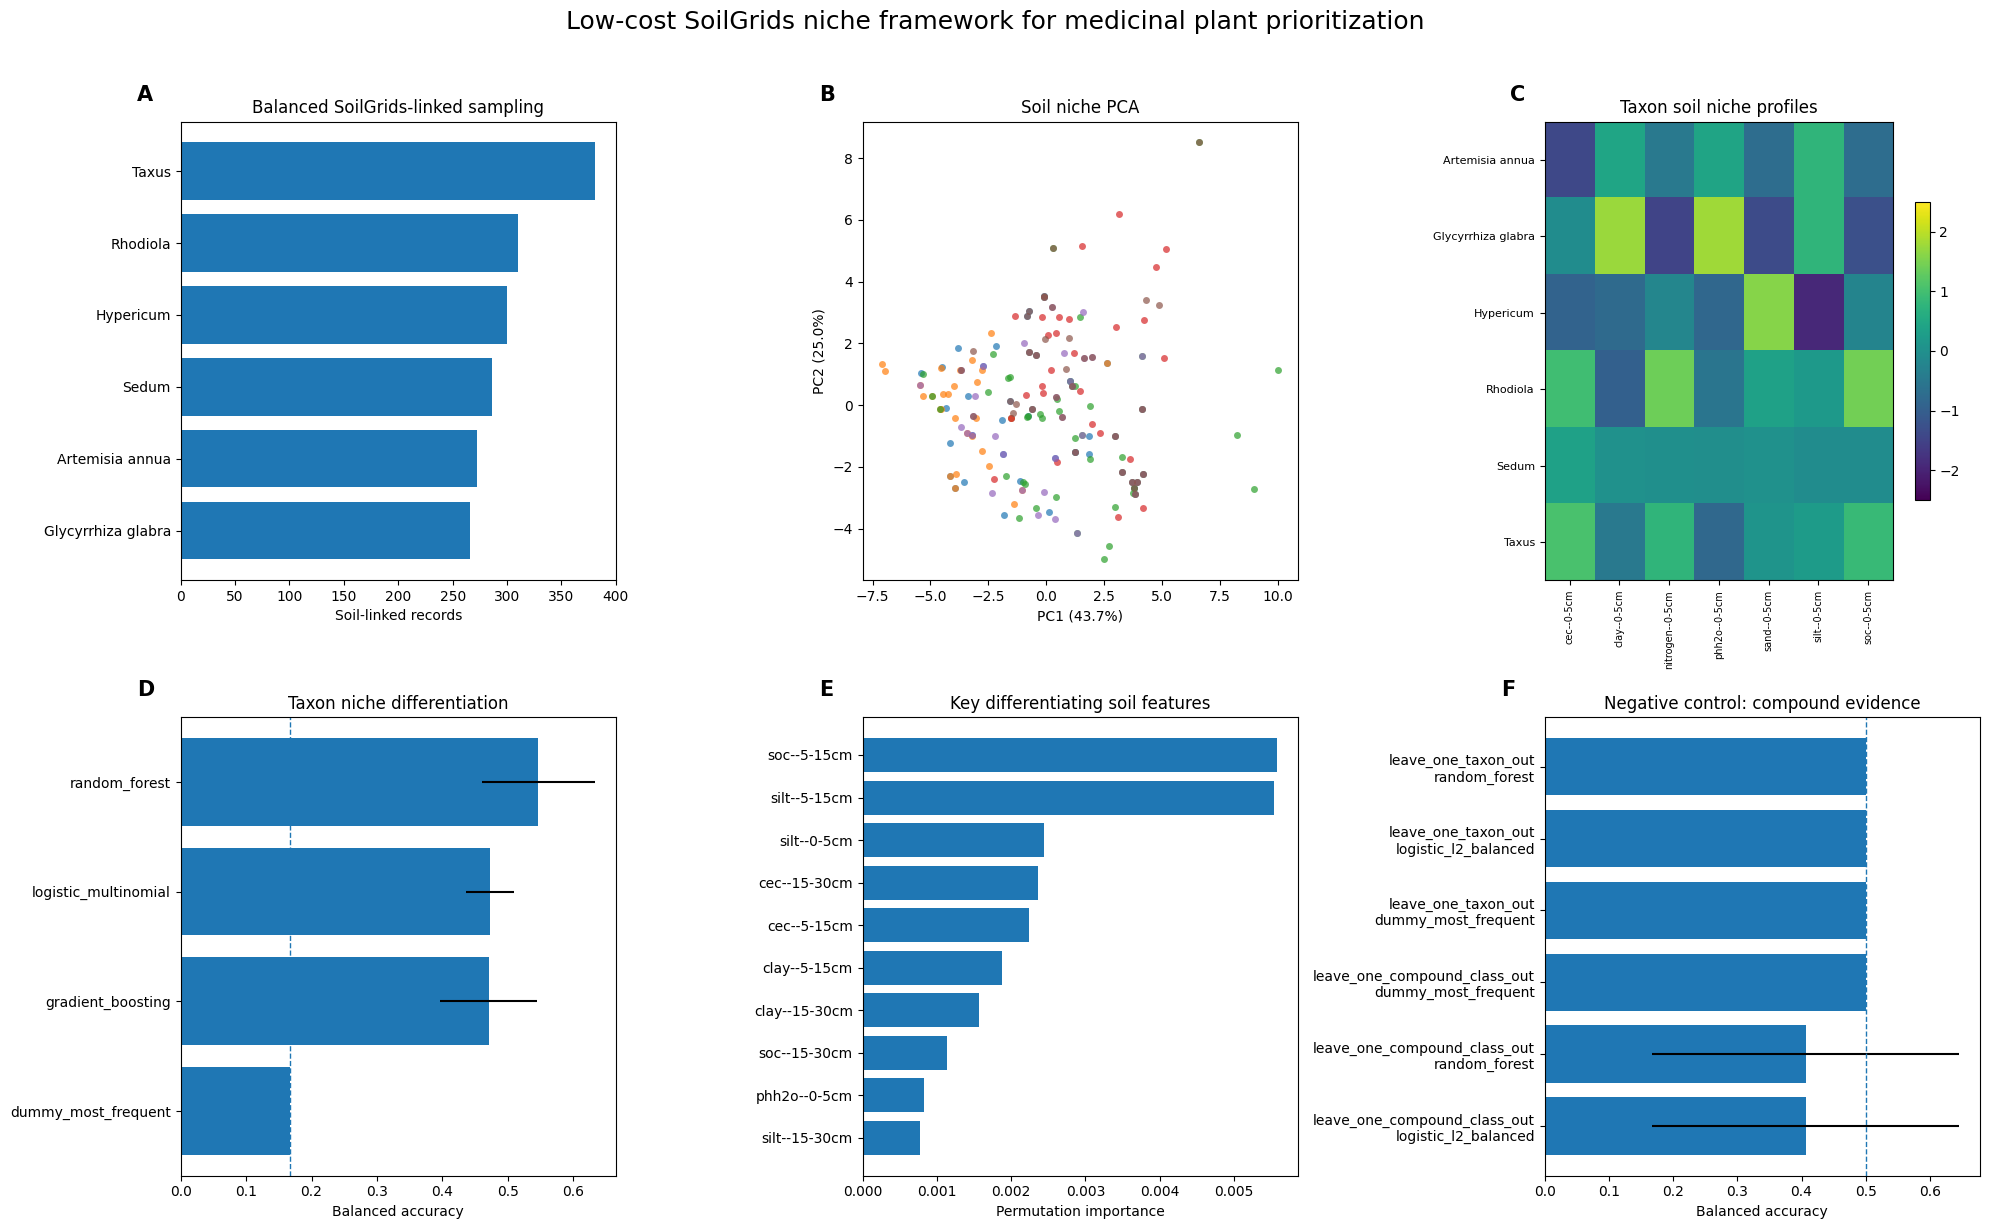

In [47]:
# ============================================================
# Figure S6 / Main Figure candidate
# Composite Q1-style SoilGrids niche framework panel
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.reshape(-1)

# A: taxon coverage
ax = axes[0]
plot_df = taxon_coverage_qc_df.sort_values("n_soil_occurrences")
ax.barh(plot_df["input_taxon"], plot_df["n_soil_occurrences"])
ax.set_xlabel("Soil-linked records")
ax.set_title("Balanced SoilGrids-linked sampling")
_panel(ax, "A")

# B: block-level PCA
ax = axes[1]
for taxon, sub in block_pca_scores_df.groupby("input_taxon"):
    ax.scatter(sub["PC1"], sub["PC2"], s=25, alpha=0.7, linewidths=0, label=taxon)
ax.set_xlabel(f"PC1 ({pca_block.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_block.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("Soil niche PCA")
_panel(ax, "B")

# C: soil niche profile
ax = axes[2]
im = ax.imshow(taxon_soil_profile_z.values, aspect="auto", vmin=-2.5, vmax=2.5)
ax.set_yticks(range(len(taxon_soil_profile_z.index)))
ax.set_yticklabels(taxon_soil_profile_z.index, fontsize=8)
ax.set_xticks(range(len(taxon_soil_profile_z.columns)))
ax.set_xticklabels([_short_feature_name(c) for c in taxon_soil_profile_z.columns], rotation=90, fontsize=7)
ax.set_title("Taxon soil niche profiles")
fig.colorbar(im, ax=ax, shrink=0.65)
_panel(ax, "C")

# D: taxon classifier performance
ax = axes[3]
plot_df = taxon_cv_summary_df.sort_values("balanced_accuracy_mean")
ax.barh(plot_df["model"], plot_df["balanced_accuracy_mean"], xerr=plot_df["balanced_accuracy_sd"].fillna(0))
ax.axvline(1 / occurrence_soil_df["taxon_id"].nunique(), linestyle="--", linewidth=1)
ax.set_xlabel("Balanced accuracy")
ax.set_title("Taxon niche differentiation")
_panel(ax, "D")

# E: soil feature importance
ax = axes[4]
if "taxon_importance_df" in globals() and not taxon_importance_df.empty:
    top_imp = taxon_importance_df.head(10).iloc[::-1]
    ax.barh([_short_feature_name(x) for x in top_imp["soil_feature"]], top_imp["importance_mean"])
    ax.set_xlabel("Permutation importance")
else:
    ax.text(0.5, 0.5, "No importance table", ha="center", va="center")
ax.set_title("Key differentiating soil features")
_panel(ax, "E")

# F: compound negative control
ax = axes[5]
if "compound_negative_summary_df" in globals() and not compound_negative_summary_df.empty:
    neg = compound_negative_summary_df.copy().sort_values("balanced_accuracy_mean")
    labels = neg["scheme"] + "\n" + neg["model"]
    ax.barh(labels, neg["balanced_accuracy_mean"], xerr=neg["balanced_accuracy_sd"].fillna(0))
    ax.axvline(0.5, linestyle="--", linewidth=1)
    ax.set_xlabel("Balanced accuracy")
else:
    ax.text(0.5, 0.5, "No valid compound negative-control result", ha="center", va="center")
ax.set_title("Negative control: compound evidence")
_panel(ax, "F")

fig.suptitle(
    "Low-cost SoilGrids niche framework for medicinal plant prioritization",
    fontsize=18,
    y=1.02
)

fig.tight_layout()
_save_pubfig(fig, "figureS6_composite_soilgrids_niche_framework")
plt.show()

## 8. Outputs

Primary outputs:

- `derived/soil_niche_occurrence_table_deduplicated.tsv`
- `derived/soil_niche_pca_scores_by_occurrence.tsv`
- `derived/soil_niche_pca_loadings.tsv`
- `derived/taxon_soil_niche_classification_summary.tsv`
- `derived/taxon_soil_niche_permutation_importance.tsv`
- `derived/negative_control_compound_level_soil_ml_summary.tsv`
- `derived/notebook3S_v2_qc_and_interpretation_report.md`

Main figures:

- `figures/figure1_soil_niche_revised_design_qc.png/pdf`
- `figures/figure2_soil_niche_pca_feature_structure.png/pdf`
- `figures/figure3_taxon_soil_niche_differentiation.png/pdf`
- `figures/figure4_compound_evidence_annotation_heatmap.png/pdf`
- `figures/figure5_compound_annotation_negative_control_ml.png/pdf`

Manuscript framing:

> SoilGrids-derived soil niche features differentiate medicinal plant taxa and provide ecological context for prioritization, while soil-only features do not generalize to compound-level medicinal evidence.

This is stronger and more defensible than claiming SoilGrids predicts medicinal compound accumulation.

In [34]:
import shutil
from google.colab import files

# Create a zip archive of the project directory
output_archive_name = f"{CONFIG['project_dir']}.zip"
shutil.make_archive(CONFIG['project_dir'], 'zip', PROJECT)

print(f"Created zip archive: {output_archive_name}")

# Provide a link to download the file
files.download(output_archive_name)

Created zip archive: soilgrids_notebook3S_v2_soil_niche_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>